# Bechdel Test Prediction — Comprehensive ML Experiment Suite

**University Group Project — ML Foundations Course**

---

## Research Questions

1. Is the model learning **meaningful representation-related patterns** from pre-release movie metadata?
2. Or is it relying on **shortcut / confounding features** (genre stereotypes, popularity, temporal trends, enrichment artifacts)?

## Notebook Structure
| Section | Content |
|---------|--------|
| 1 | Setup & Imports |
| 2 | Load Data |
| 3 | Feature Engineering & Fixed Train/Test Split |
| 4 | Helper Functions |
| 5 | Reusable Experiment Runner |
| 6 | Exploratory Data Analysis |
| 7 | Model Selection — Baseline (all models) |
| 8 | Imputation Strategy Experiments |
| 9 | Missingness-as-Signal Experiment |
| 10 | Ablation Experiments |
| 11 | Results Comparison Tables |
| 12 | Visualisations & Interpretation |
| 13 | Final Conclusions |

**Design rules (enforced throughout):**
- Train/test split is fixed across every experiment (`seed=42`, `stratify=y`, 80/20).
- Every experiment builds a **fresh, unfitted pipeline** — no object reuse across runs.
- Preprocessing (imputation, scaling, OHE, TF-IDF) is **fitted only on training folds** during CV.
- The held-out test set is used only for final evaluation, never for model or hyperparameter selection.

## 1. Setup & Imports

In [ ]:
import os, sys, warnings
sys.path.insert(0, os.path.abspath('../src'))
warnings.filterwarnings('ignore')

from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, PrecisionRecallDisplay
from sklearn.inspection import permutation_importance as perm_imp
from sklearn.calibration import calibration_curve
from sklearn.model_selection import learning_curve as lc
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
)

# ── Optional heavy dependencies ───────────────────────────────────────────
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print('SHAP not installed; SHAP plots will be skipped.  pip install shap')

try:
    import missingno as msno
    HAS_MSNO = True
except ImportError:
    HAS_MSNO = False

# ── Project source modules ────────────────────────────────────────────────
import os, sys, warnings
sys.path.insert(0, os.path.abspath('src'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
...
from src.data_loader2 import load_data2
from src.preprocessing2 import (
    engineer_features2, NUMERIC_FEATURES2, BINARY_FEATURES2, CATEGORICAL_FEATURES2,
    GENRE_LIST2, _DensePlotUnion2, ColumnSelector2
)
from src.models2 import get_classifiers2, HAS_XGB2

# ── Global experiment constants ───────────────────────────────────────────
RANDOM_STATE = 42
CV_SPLITS    = 5
TEST_SIZE    = 0.20
SCORING      = 'roc_auc'

# ── Plotting style ────────────────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('colorblind')
COLORS = sns.color_palette('colorblind', 12)

print('Environment ready.')
print(f'  SHAP available:      {HAS_SHAP}')
print(f'  missingno available: {HAS_MSNO}')
print(f'  XGBoost available:   {HAS_XGB2}')


Environment ready.
  SHAP available:      True
  missingno available: True
  XGBoost available:   True


## 2. Load Data

`movies_complete.csv` is the fully merged dataset (Bechdel/IMDb + TMDb enrichment + Wikidata supplement). Films without a Bechdel rating are automatically excluded by the loader.

**Expected missingness:** budget, revenue, and TMDb popularity are missing for ~50–78% of films depending on the dataset version — this is by design, not a data quality issue. The enrichment comes from a separate source with only partial overlap.

In [ ]:

DATA_DIR      = os.path.abspath('data')
COMPLETE_PATH = os.path.join(DATA_DIR, 'movies_complete.csv')
BECHDEL_PATH  = os.path.join(DATA_DIR, 'Bechdel_IMDB_Merge0524.csv')
TMDB_PATH     = os.path.join(DATA_DIR, 'movies_enriched_5k.csv')

# Verify paths exist; adjust if necessary
if not os.path.exists(BECHDEL_PATH):
    print(f'Warning: BECHDEL_PATH not found: {BECHDEL_PATH}')
    print(f'Files in {DATA_DIR}:')
    print(os.listdir(DATA_DIR) if os.path.exists(DATA_DIR) else 'DATA_DIR does not exist')

df_raw2 = load_data2(
    bechdel_path2=BECHDEL_PATH,
    tmdb_path2=TMDB_PATH,
    complete_path2=COMPLETE_PATH if os.path.exists(COMPLETE_PATH) else None,
)

print(f'\nDataset shape: {df_raw2.shape}')
vc = df_raw2['bechdel_pass'].value_counts()
print(f'Target distribution: Pass={vc.get(1,0):,} ({vc.get(1,0)/len(df_raw2):.1%})  '
      f'Fail={vc.get(0,0):,} ({vc.get(0,0)/len(df_raw2):.1%})')
print('\nMissingness rates (%):')
miss = df_raw2.isnull().mean().mul(100).round(1)
print(miss[miss > 0].to_string())
df_raw2.head(3)

Files in C:\Users\alpk9\ML-fundamentals-2026\data:
['movies_complete.csv', 'movies_complete_fixed-3.csv', 'movies_enriched_5k.csv']
[data_loader] Dropped 1,618 unlabelled movies (no Bechdel rating). 9,718 labelled films retained.
[data_loader] Loaded 9,718 films from complete dataset.

Dataset shape: (9718, 15)
Target distribution: Pass=5,602 (57.6%)  Fail=4,116 (42.4%)

Missingness rates (%):
runtime                 0.1
budget                 55.2
revenue                56.7
tmdb_popularity        65.2
cast_size               1.2
has_female_director     2.2


,imdb_id,title,year,runtime,imdb_rating,num_votes,bechdel_score,bechdel_pass,genres,budget,revenue,tmdb_popularity,cast_size,has_female_director,plot
0,tt0000009,Miss Jerry,1894.0,45.0,5.4,212.0,0.0,0,Romance,NaN,NaN,NaN,0.0,0.0,1894 film directed by Alexander Black
1,tt0000574,"Story of the Kelly Gang, The",1906.0,70.0,6.0,903.0,1.0,0,Action|Adventure|Biography,NaN,NaN,NaN,1.0,0.0,1906 film
2,tt0002101,Cleopatra,1912.0,100.0,5.1,622.0,2.0,0,Drama|History,NaN,NaN,NaN,3.0,0.0,1912 film by Charles L. Gaskill


## 2.5 Raw Feature Distributions

Before applying any transformations we inspect the **raw distributions** of the numeric features.

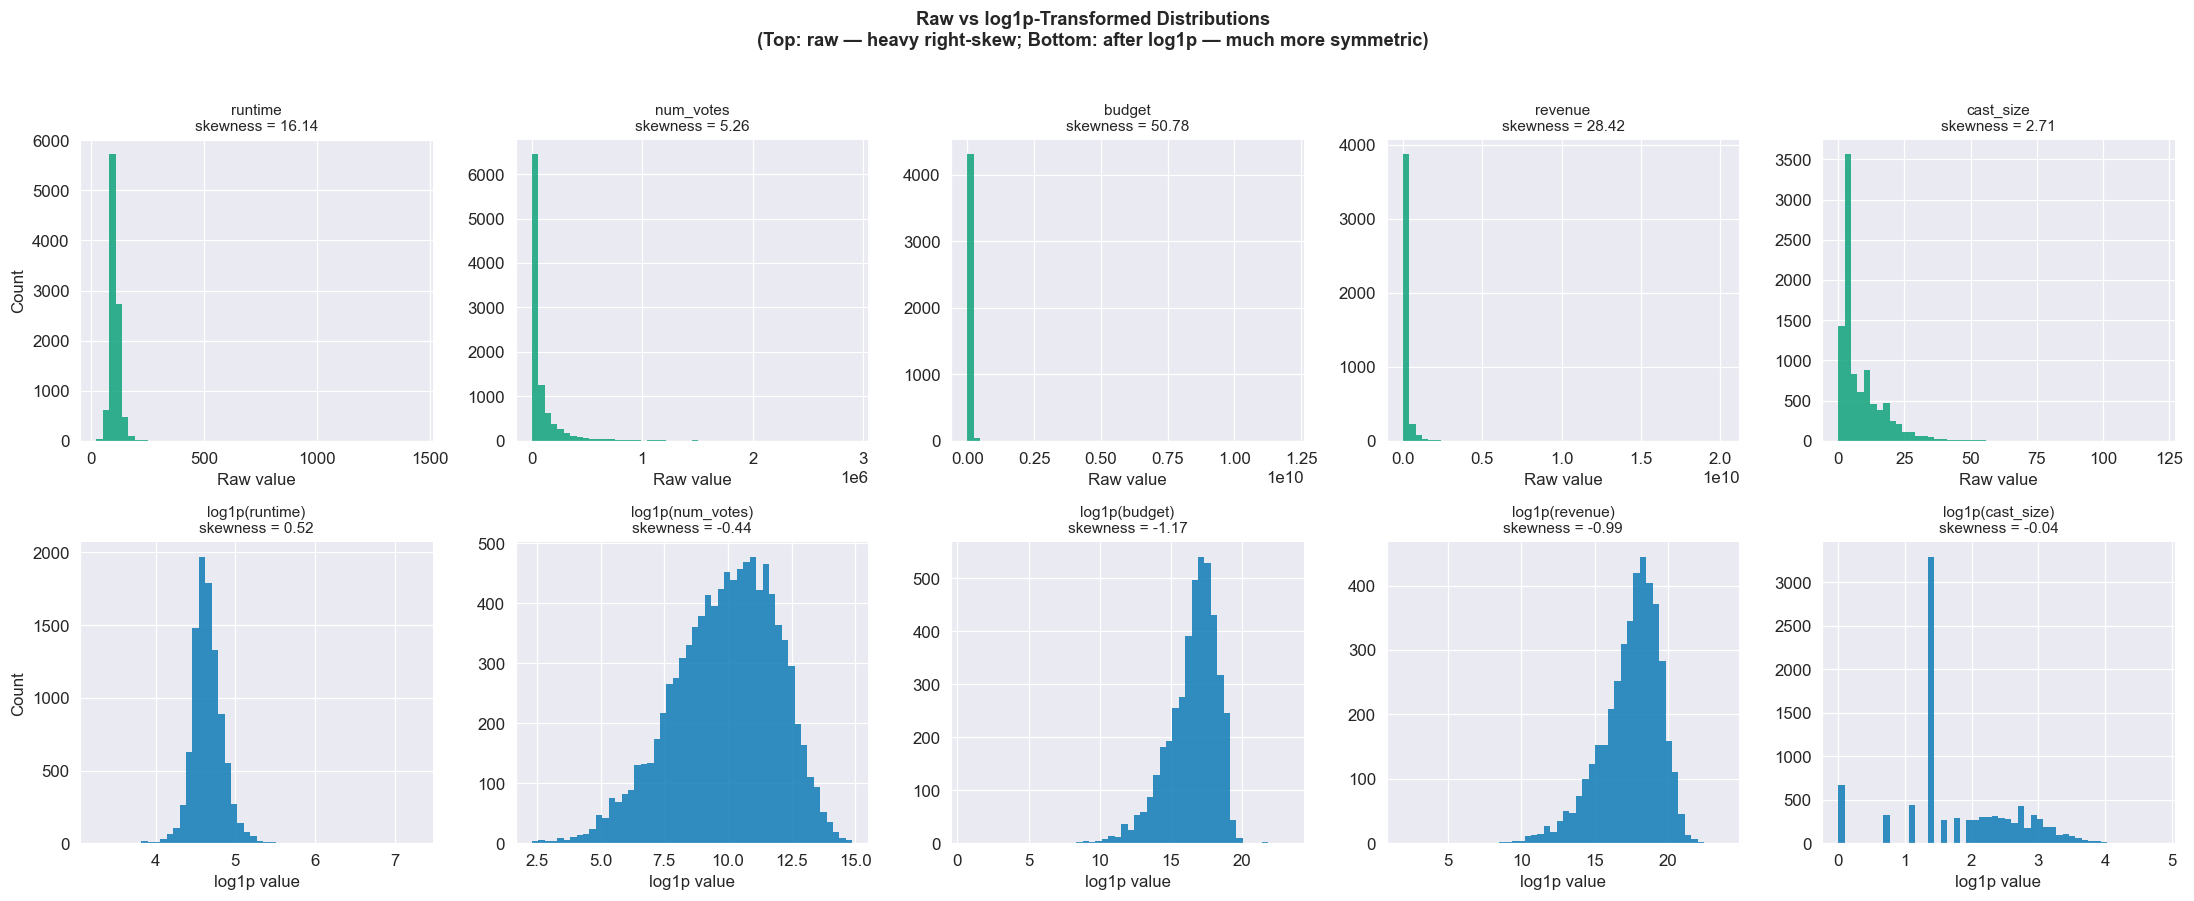

Skewness Summary:
Feature            Raw skewness    log1p skewness  Interpretation
------------------------------------------------------------------------
runtime                   16.14              0.52  highly skewed, log transform warranted
num_votes                  5.26             -0.44  highly skewed, log transform warranted
budget                    50.78             -1.17  highly skewed, log transform warranted
revenue                   28.42             -0.99  highly skewed, log transform warranted
cast_size                  2.71             -0.04  highly skewed, log transform warranted


In [ ]:
# ── 2.5  Raw distributions — justify log1p transforms ────────────────────

raw_cols = ['runtime', 'num_votes', 'budget', 'revenue', 'cast_size']
raw_cols = [c for c in raw_cols if c in df_raw2.columns]

fig, axes = plt.subplots(2, len(raw_cols), figsize=(4 * len(raw_cols), 8))

for i, col in enumerate(raw_cols):
    data_raw = df_raw2[col].dropna()
    data_log = np.log1p(data_raw.clip(0))

    skew_raw = data_raw.skew()
    skew_log = data_log.skew()

    ax_top = axes[0, i]
    ax_top.hist(data_raw, bins=50, color=COLORS[2], alpha=0.8, edgecolor='none')
    ax_top.set_title(f'{col}\nskewness = {skew_raw:.2f}', fontsize=10)
    ax_top.set_ylabel('Count' if i == 0 else '')
    ax_top.set_xlabel('Raw value')

    ax_bot = axes[1, i]
    ax_bot.hist(data_log, bins=50, color=COLORS[0], alpha=0.8, edgecolor='none')
    ax_bot.set_title(f'log1p({col})\nskewness = {skew_log:.2f}', fontsize=10)
    ax_bot.set_ylabel('Count' if i == 0 else '')
    ax_bot.set_xlabel('log1p value')

plt.suptitle(
    'Raw vs log1p-Transformed Distributions\n'
    '(Top: raw — heavy right-skew; Bottom: after log1p — much more symmetric)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

print('Skewness Summary:')
print(f'{"Feature":<15}  {"Raw skewness":>14}  {"log1p skewness":>16}  Interpretation')
print('-' * 72)
for col in raw_cols:
    data_raw = df_raw2[col].dropna()
    sk_raw = data_raw.skew()
    sk_log = np.log1p(data_raw.clip(0)).skew()
    if abs(sk_raw) > 2:
        interp = 'highly skewed, log transform warranted'
    elif abs(sk_raw) > 1:
        interp = 'skewed, log transform helps'
    else:
        interp = 'mild skew'
    print(f'{col:<15}  {sk_raw:>14.2f}  {sk_log:>16.2f}  {interp}')

Log transforms (`log1p`) are appropriate when data is **heavily right-skewed** (long positive tail):
they compress extreme values, reduce outlier influence, and bring distributions closer to symmetry —
all of which benefit linear models and distance-based algorithms.

*  **Rule of thumb:** skewness > 1 indicates meaningful skew; > 2 is commonly called *highly skewed*.
        A well-behaved feature after `log1p` should have |skewness| closer to 0.


## 2.6 Feature-Target Correlations

Pearson correlation of each raw numeric feature with `bechdel_pass`.
This gives a quick ranked view of which features carry the most linear signal
before any transformation or modelling and flags features with near-zero
correlation that are unlikely to help any model.

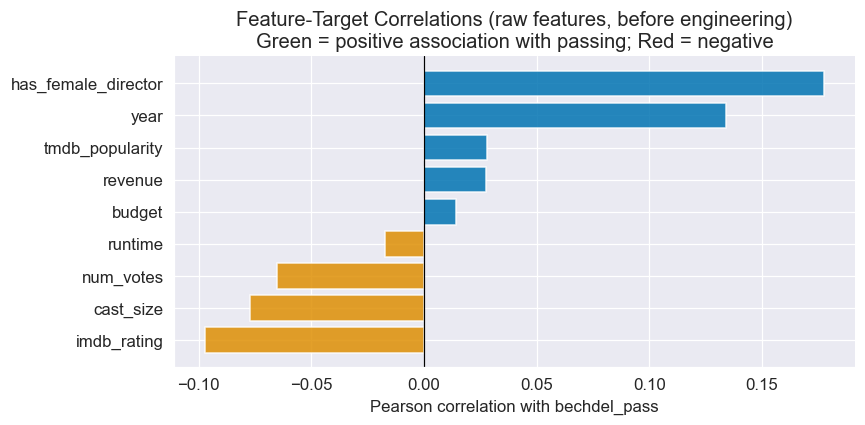

Top positive correlates:
budget                 0.014117
revenue                0.027512
tmdb_popularity        0.027793
year                   0.134047
has_female_director    0.177486

Top negative correlates:
imdb_rating   -0.097057
cast_size     -0.077140
num_votes     -0.065395
runtime       -0.017338
budget         0.014117


In [ ]:
# ── 2.6  Feature-target correlation bar chart ─────────────────────────────
# Computed on raw df_raw2 before any feature engineering or splitting.

num_cols = df_raw2.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in ('bechdel_pass', 'bechdel_score')]

corr_target = (
    df_raw2[num_cols + ['bechdel_pass']]
    .corr()['bechdel_pass']
    .drop('bechdel_pass')
    .dropna()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, max(4, len(corr_target) * 0.4)))
bar_colors = [COLORS[0] if v >= 0 else COLORS[1] for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=bar_colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with bechdel_pass')
ax.set_title('Feature-Target Correlations (raw features, before engineering)\n'
             'Green = positive association with passing; Red = negative')
plt.tight_layout()
plt.show()

print('Top positive correlates:')
print(corr_target.tail(5).to_string())
print('\nTop negative correlates:')
print(corr_target.head(5).to_string())

The strongest positive correlations appear for:
- `has_female_director`
- `year`

This suggests that movies directed by women and more recent films are somewhat more likely to pass the Bechdel Test. The positive correlation with `year` is consistent with broader historical trends in gender representation across decades.

Several popularity-related variables (`num_votes`, `imdb_rating`, `cast_size`) exhibit small negative correlations with the target, although these relationships are relatively weak.

Importantly, all observed correlations remain fairly modest in magnitude. This suggests that no single feature alone strongly determines the target outcome, motivating the use of multivariate machine learning models capable of capturing more complex interactions between features.

## 2.7 Correlation Heatmap

Pairwise correlations between all raw numeric features (including `bechdel_pass`).
Strongly correlated feature pairs (e.g. `budget` and `revenue`) signal **multicollinearity**
— they carry overlapping information, which motivates the ablation experiments in Section 10.

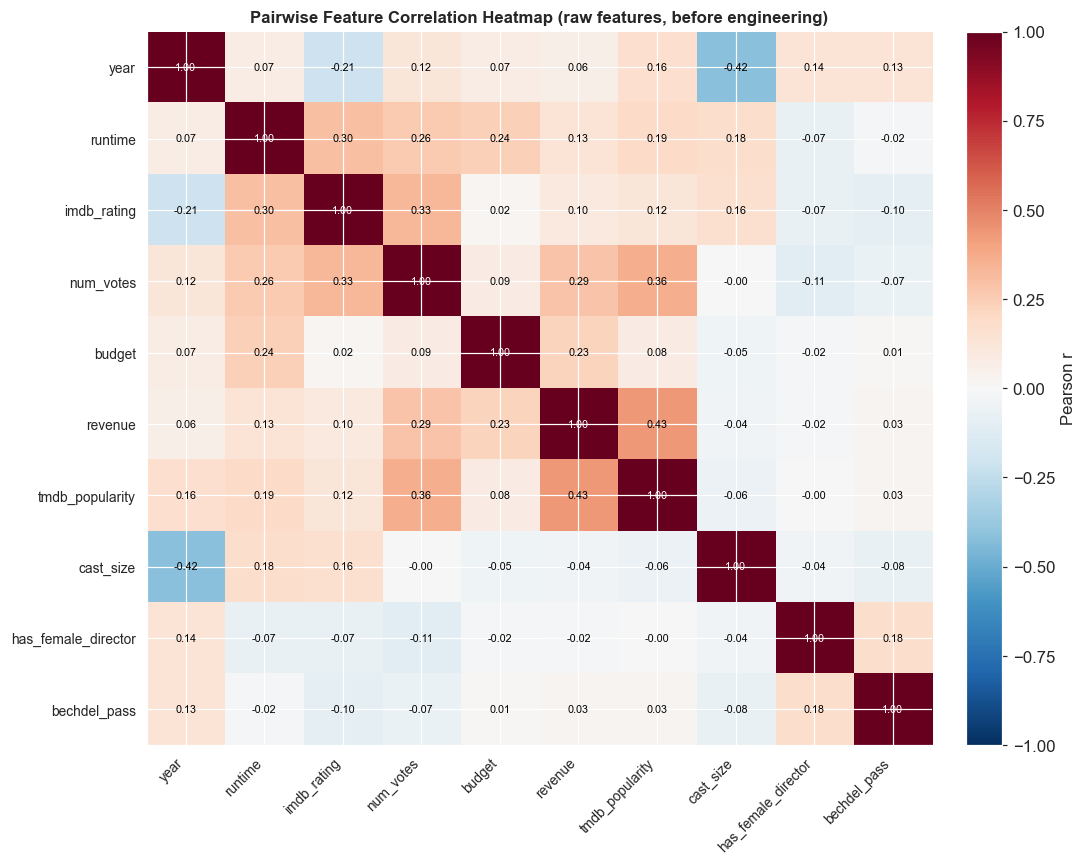

In [ ]:
# ── 2.7  Correlation heatmap ──────────────────────────────────────────────
# Computed on raw df_raw2 before any feature engineering or splitting.

heatmap_cols = [c for c in num_cols if df_raw2[c].notna().sum() > 100] + ['bechdel_pass']
corr_matrix = df_raw2[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')

ticks = range(len(corr_matrix.columns))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr_matrix.columns, fontsize=9)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        val = corr_matrix.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color='black' if abs(val) < 0.6 else 'white')

ax.set_title('Pairwise Feature Correlation Heatmap (raw features, before engineering)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

No extremely strong correlations are present among most predictors, suggesting that the feature set does not suffer from severe multicollinearity. This is beneficial for both interpretability and model stability. Based on this analysis, we did not identify a strong need to remove features solely due to multicollinearity concerns.

## 3. Feature Engineering & Fixed Train/Test Split

All feature engineering is **row-local and deterministic**: log-transforms, decade bucketing, and genre one-hot flags depend only on a row's own values, so applying them before the split introduces zero leakage.

Raw columns (`runtime`, `num_votes`, `budget`, `revenue`, `cast_size`, `genres`) are replaced by their engineered versions. The raw columns and identifiers are dropped from `X`; the `plot` column is kept so TF-IDF experiments can use it inside the pipeline.

> **The train/test split is fixed for the entire notebook.** All experiments use exactly the same split.

In [ ]:
# Row-local engineering, safe to do before split
df = engineer_features2(df_raw2)

TARGET = 'bechdel_pass'

# Columns to exclude from X:
#   identifiers, the raw columns (replaced by engineered versions), and the target
DROP_COLS = [
    'imdb_id', 'title',
    'bechdel_score', 'bechdel_pass',  # target leakage
    'runtime', 'num_votes',           # replaced by log_runtime, log_num_votes
    'budget', 'revenue', 'cast_size', # replaced by log_* versions
    'genres',                         # replaced by genre_* one-hots
    # 'plot' intentionally KEPT for optional TF-IDF inside the pipeline
]

X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows')
print(f'Train pass rate: {y_train.mean():.3f}  |  Test pass rate: {y_test.mean():.3f}')
print(f'\nAll feature columns ({len(X_train.columns)}):')
print(list(X_train.columns))

Train: 7,774 rows  |  Test: 1,944 rows
Train pass rate: 0.576  |  Test pass rate: 0.577

All feature columns (31):
['year', 'imdb_rating', 'tmdb_popularity', 'has_female_director', 'plot', 'log_runtime', 'log_num_votes', 'log_budget', 'log_revenue', 'log_cast_size', 'decade', 'genre_action', 'genre_adventure', 'genre_animation', 'genre_biography', 'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_drama', 'genre_fantasy', 'genre_history', 'genre_horror', 'genre_music', 'genre_musical', 'genre_mystery', 'genre_romance', 'genre_sci_fi', 'genre_sport', 'genre_thriller', 'genre_war', 'genre_western']


## 4. Helper Functions

### 4a. Missingness Indicator Creator
For the **missingness-as-signal experiment** we add binary flags (`budget_missing`, `revenue_missing`, etc.) encoding whether each TMDb-derived feature was absent. These flags are computed from the data before any pipeline fitting, so they are safe to include as features.

### 4b. Feature Group Definitions
We define which columns belong to each feature group for ablation experiments. All definitions are derived from `X_train.columns` so they reflect exactly what is available after the split.

### 4c. Fresh Pipeline Builder
`build_experiment_pipeline()` constructs a fully new, unfitted sklearn Pipeline every time it is called. The imputation strategy, TF-IDF inclusion, and feature lists are all configurable per call.

In [ ]:
# ── 4a. Missingness indicators ────────────────────────────────────────────
ENRICHMENT_COLS_MAP = {
    'log_budget':      'budget_missing',
    'log_revenue':     'revenue_missing',
    'tmdb_popularity': 'popularity_missing',
    'log_cast_size':   'cast_size_missing',
}
PLOT_MISSING_COL = 'plot_missing'


def add_missingness_indicators(X: pd.DataFrame) -> pd.DataFrame:
    """Add binary missingness indicator columns for enrichment-derived features."""
    X = X.copy()
    for feat_col, indicator_name in ENRICHMENT_COLS_MAP.items():
        X[indicator_name] = X[feat_col].isna().astype(int) if feat_col in X.columns else 0
    # plot_missing: empty string or NaN means no plot was available
    if 'plot' in X.columns:
        X[PLOT_MISSING_COL] = X['plot'].fillna('').eq('').astype(int)
    else:
        X[PLOT_MISSING_COL] = 0
    return X


# ── 4b. Feature group definitions for ablations ───────────────────────────
GENRE_FEATURES = [c for c in X_train.columns if c.startswith('genre_')]

POPULARITY_FEATURES = [
    c for c in ['imdb_rating', 'log_num_votes', 'log_budget', 'log_revenue', 'tmdb_popularity']
    if c in X_train.columns
]

TEMPORAL_FEATURES = [c for c in ['year', 'decade'] if c in X_train.columns]

TMDB_ENRICHMENT_FEATURES = [
    c for c in ['log_budget', 'log_revenue', 'tmdb_popularity', 'log_cast_size', 'has_female_director']
    if c in X_train.columns
]

print('Feature group sizes:')
print(f'  Genre features:      {len(GENRE_FEATURES):>3}  {GENRE_FEATURES[:3]}...')
print(f'  Popularity features: {len(POPULARITY_FEATURES):>3}  {POPULARITY_FEATURES}')
print(f'  Temporal features:   {len(TEMPORAL_FEATURES):>3}  {TEMPORAL_FEATURES}')
print(f'  TMDb enrichment:     {len(TMDB_ENRICHMENT_FEATURES):>3}  {TMDB_ENRICHMENT_FEATURES}')

Feature group sizes:
  Genre features:       20  ['genre_action', 'genre_adventure', 'genre_animation']...
  Popularity features:   5  ['imdb_rating', 'log_num_votes', 'log_budget', 'log_revenue', 'tmdb_popularity']
  Temporal features:     2  ['year', 'decade']
  TMDb enrichment:       5  ['log_budget', 'log_revenue', 'tmdb_popularity', 'log_cast_size', 'has_female_director']


In [ ]:
# ── 4c. Fresh pipeline builder ────────────────────────────────────────────
def build_experiment_pipeline(
    clf,
    numeric_features,
    categorical_features,
    binary_features,
    imputation_strategy='median',
    use_plot_tfidf=False,
):

    valid_strategies = ('mean', 'median', 'most_frequent')
    num_strategy = imputation_strategy if imputation_strategy in valid_strategies else 'median'

    dense_ct = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('impute', SimpleImputer(strategy=num_strategy)),
                ('scale',  StandardScaler()),
            ]), numeric_features),
            ('cat', Pipeline([
                ('impute', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore',
                                         sparse_output=False, drop='first')),
            ]), categorical_features),
            ('bin', SimpleImputer(strategy='constant', fill_value=0), binary_features),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )

    if use_plot_tfidf:
        tfidf_pipe = Pipeline([
            ('sel',   ColumnSelector2('plot')),
            ('tfidf', TfidfVectorizer(
                max_features=150, sublinear_tf=True,
                min_df=3, ngram_range=(1, 2), stop_words='english',
            )),
        ])
        preprocessor = _DensePlotUnion2(dense_ct, tfidf_pipe)
    else:
        preprocessor = dense_ct

    return Pipeline([
        ('preprocess', preprocessor),
        ('clf', clone(clf)),
    ])


print('Pipeline builder defined.')

Pipeline builder defined.


## 5. Reusable Experiment Runner

`run_experiment(config)` is the single entry point for every experiment. It enforces the leakage-safe protocol:

1. **Prepare data** — optionally add missingness indicators and/or drop feature groups.
2. **Build a fresh pipeline** — new estimator objects for every call.
3. **Cross-validate on the training split only** — test set is never seen here.
4. **Fit on the full training split.**
5. **Evaluate on the held-out test split** — one call per experiment, for reporting only.
6. **Log results** to the shared `ALL_RESULTS` list.

Config schema:
```
experiment_name : str   — human-readable label
model_key       : str   — 'dummy' | 'logreg' | 'tree' | 'rf' | 'xgb'
imputation      : str   — 'median' | 'mean' | 'most_frequent'
use_tfidf       : bool  — include TF-IDF plot features
add_missingness : bool  — add missingness indicator features
drop_features   : list  — column names to remove before fitting
ablation_type   : str   — experiment category tag
notes           : str   — free-text annotation
```

In [ ]:
##%%
ALL_RESULTS = []   # shared results log (metrics only, no heavy objects)


def run_experiment(config: dict) -> dict:
    name       = config.get('experiment_name', 'unnamed')
    model_key  = config.get('model_key', 'xgb')
    imputation = config.get('imputation', 'median')
    use_tfidf  = config.get('use_tfidf', False)
    add_miss   = config.get('add_missingness', False)
    drop_feats = config.get('drop_features', [])
    notes      = config.get('notes', '')

    # ── 1. Prepare data ───────────────────────────────────────────────────
    X_tr = X_train.copy()
    X_te = X_test.copy()

    if add_miss:
        X_tr = add_missingness_indicators(X_tr)
        X_te = add_missingness_indicators(X_te)

    cols_to_drop = [c for c in drop_feats if c in X_tr.columns]
    X_tr = X_tr.drop(columns=cols_to_drop, errors='ignore')
    X_te = X_te.drop(columns=cols_to_drop, errors='ignore')

    # ── 2. Determine feature lists ────────────────────────────────────────
    miss_indicator_cols = []
    if add_miss:
        miss_indicator_cols = [
            c for c in list(ENRICHMENT_COLS_MAP.values()) + [PLOT_MISSING_COL]
            if c in X_tr.columns
        ]

    num_feats = [c for c in NUMERIC_FEATURES2    if c in X_tr.columns]
    cat_feats = [c for c in CATEGORICAL_FEATURES2 if c in X_tr.columns]
    bin_feats = [c for c in BINARY_FEATURES2      if c in X_tr.columns]
    bin_feats = bin_feats + miss_indicator_cols

    if not (num_feats or cat_feats or bin_feats):
        print(f'  [SKIP] {name}: no features remaining.')
        return {}

    # ── 3. Get classifier ─────────────────────────────────────────────────
    clfs = get_classifiers2(random_state=RANDOM_STATE)
    if model_key not in clfs:
        print(f'  [SKIP] {name}: model "{model_key}" not available.')
        return {}
    clf = clfs[model_key]

    # ── 4. Build fresh pipeline ───────────────────────────────────────────
    pipeline = build_experiment_pipeline(
        clf=clf,
        numeric_features=num_feats,
        categorical_features=cat_feats,
        binary_features=bin_feats,
        imputation_strategy=imputation,
        use_plot_tfidf=use_tfidf and 'plot' in X_tr.columns,
    )

    # ── 5. CV on training split only ─────────────────────────────────────
    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        cv_scores = cross_val_score(pipeline, X_tr, y_train, cv=cv,
                                    scoring=SCORING, n_jobs=1)
    cv_mean, cv_std = float(cv_scores.mean()), float(cv_scores.std())

    # ── 6. Fit on full training split ─────────────────────────────────────
    pipeline.fit(X_tr, y_train)

    # ── 7. Evaluate on held-out test split ────────────────────────────────
    y_pred = pipeline.predict(X_te)
    y_prob = pipeline.predict_proba(X_te)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob)
    ap   = average_precision_score(y_test, y_prob)

    row = {
        'experiment_name':   name,
        'model_name':        model_key,
        'imputation_method': imputation,
        'ablation_type':     config.get('ablation_type', 'none'),
        'use_tfidf':         use_tfidf,
        'add_missingness':   add_miss,
        'cv_mean':           round(cv_mean, 4),
        'cv_std':            round(cv_std,  4),
        'accuracy':          round(acc,  4),
        'precision':         round(prec, 4),
        'recall':            round(rec,  4),
        'f1':                round(f1,   4),
        'roc_auc':           round(auc,  4),
        'avg_precision':     round(ap,   4),
        'notes':             notes,
    }
    ALL_RESULTS.append(row)

    # Return everything including heavy objects for downstream visualisation
    result = dict(row)
    result.update({'_pipeline': pipeline, '_y_pred': y_pred,
                   '_y_prob': y_prob, '_X_te': X_te})

    print(f'  {name:<58} CV={cv_mean:.4f}±{cv_std:.4f}  '
          f'TestAUC={auc:.4f}  F1={f1:.4f}')
    return result


print('run_experiment() defined.  ALL_RESULTS initialised.')


run_experiment() defined.  ALL_RESULTS initialised.


##%% md
## 6. Exploratory Data Analysis

Before running any experiments we examine the data to understand:
- Target class balance
- Genre-level pass rates (potential shortcut signals)
- Temporal trends in Bechdel pass rates
- Missingness patterns and whether they correlate with the target (enrichment artifacts)
- Feature distributions by Bechdel outcome

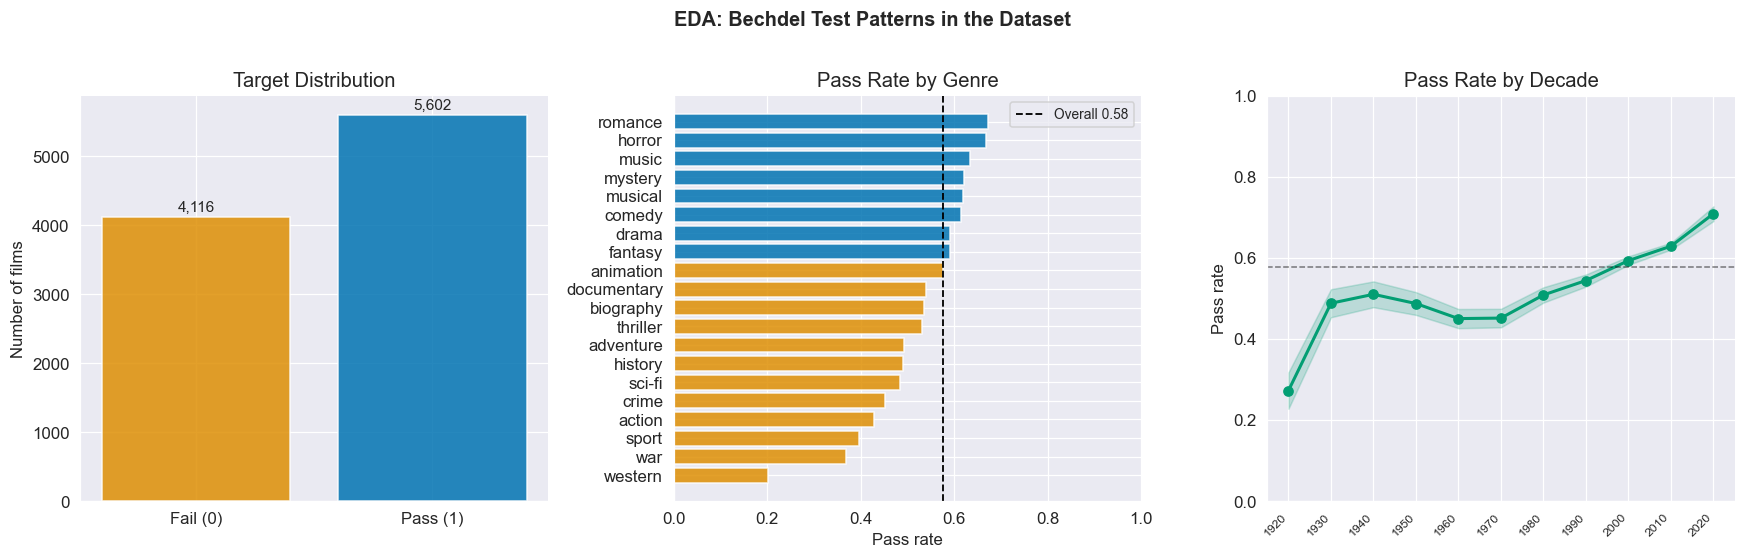

In [ ]:
##%%
# ── 6.1  Target distribution + genre pass rates + temporal trends ─────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Target counts
ax = axes[0]
vc = df_raw2['bechdel_pass'].value_counts()
ax.bar(['Fail (0)', 'Pass (1)'], [vc.get(0, 0), vc.get(1, 0)],
       color=[COLORS[1], COLORS[0]], alpha=0.85)
ax.set_title('Target Distribution')
ax.set_ylabel('Number of films')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10)

# Genre pass rates (horizontal bar)
ax = axes[1]
genre_pass = {}
for g in GENRE_LIST2:
    col = f'genre_{g.replace("-", "_")}'
    if col in df.columns:
        mask = df[col] == 1
        if mask.sum() >= 30:
            genre_pass[g] = df.loc[mask, 'bechdel_pass'].mean()
genre_s = pd.Series(genre_pass).sort_values()
overall = df['bechdel_pass'].mean()
bar_colors = [COLORS[0] if v >= overall else COLORS[1] for v in genre_s.values]
ax.barh(genre_s.index, genre_s.values, color=bar_colors, alpha=0.85)
ax.axvline(overall, color='black', linestyle='--', linewidth=1.2,
           label=f'Overall {overall:.2f}')
ax.set_xlabel('Pass rate')
ax.set_title('Pass Rate by Genre')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)

# Pass rate over decades
ax = axes[2]
decade_pass = df.groupby('decade')['bechdel_pass'].agg(['mean', 'count'])
decade_pass = decade_pass[decade_pass['count'] >= 20]  # drop tiny decades
ax.plot(range(len(decade_pass)), decade_pass['mean'], 'o-', color=COLORS[2], linewidth=2)
ax.fill_between(range(len(decade_pass)),
                decade_pass['mean'] - np.sqrt(decade_pass['mean'] * (1 - decade_pass['mean']) / decade_pass['count']),
                decade_pass['mean'] + np.sqrt(decade_pass['mean'] * (1 - decade_pass['mean']) / decade_pass['count']),
                alpha=0.2, color=COLORS[2])
ax.set_xticks(range(len(decade_pass)))
ax.set_xticklabels(decade_pass.index, rotation=45, ha='right', fontsize=8)
ax.axhline(overall, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('Pass Rate by Decade')
ax.set_ylabel('Pass rate')
ax.set_ylim(0, 1)

plt.suptitle('EDA: Bechdel Test Patterns in the Dataset', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### Genre shortcuts visible:

Substantial variation exists across genres, suggesting that genre membership carries strong predictive signal.

Genres such as Romance, Horror, and Music exhibit pass rates well above the overall dataset average, while genres such as War, Western, Action, and Crime show considerably lower pass rates.

This pattern suggests that the model could partially rely on genre-related stereotypes or narrative conventions when predicting Bechdel outcomes. Because of this, we later perform genre ablation experiments to test whether the classifier is primarily learning genre information or broader representation-related patterns.

#### Temporal shortcuts visible:

The Bechdel pass rate shows a clear long-term upward trend across decades.
Movies from the 1920s–1970s generally exhibit lower pass rates, while films from the 1980s onward show progressively higher representation outcomes.

The increase becomes especially noticeable after the 1990s, with the highest pass rates appearing in the 2010s and 2020s. This suggests that temporal information may carry substantial predictive signal, likely reflecting broader cultural and industry shifts in gender representation over time.

Both patterns could lead to shortcut learning.

### 6.1a Dataset Coverage Over Time

The pass-rate trend above may reflect sampling bias. If older decades have very few films,
their pass rate estimates are unreliable. The chart below overlays film count per decade so we can judge this.

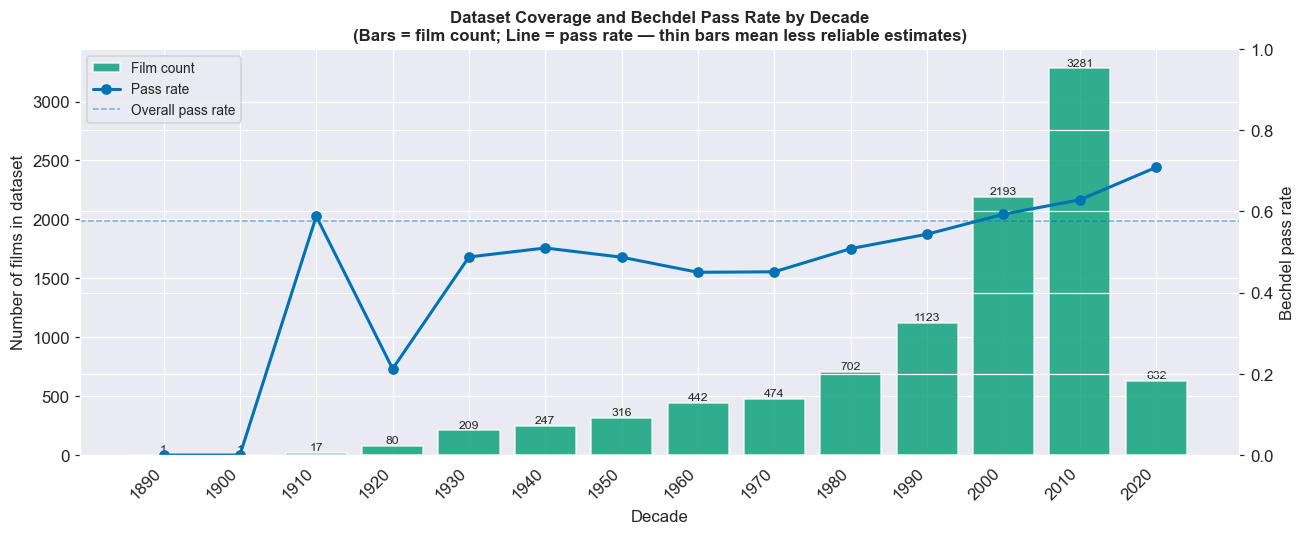

In [ ]:
# ── 6.1a  Dataset coverage over time ─────────────────────────────────────

df_raw2['decade'] = (df_raw2['year'] // 10 * 10).astype('Int64')
decade_counts = df_raw2['decade'].value_counts().sort_index()
decade_pass   = df_raw2.groupby('decade')['bechdel_pass'].mean()

fig, ax1 = plt.subplots(figsize=(12, 5))

bar_positions = range(len(decade_counts))
bars = ax1.bar(
    bar_positions, decade_counts.values,
    color=COLORS[2], alpha=0.8, label='Film count'
)
ax1.set_xticks(bar_positions)
ax1.set_xticklabels(decade_counts.index.astype(str), rotation=45, ha='right')
ax1.set_ylabel('Number of films in dataset')
ax1.set_xlabel('Decade')

ax2 = ax1.twinx()
pass_vals = [decade_pass.get(d, float('nan')) for d in decade_counts.index]
ax2.plot(bar_positions, pass_vals, 'o-', color=COLORS[0],
         linewidth=2, markersize=6, label='Pass rate')
ax2.set_ylabel('Bechdel pass rate')
ax2.set_ylim(0, 1)
ax2.axhline(df_raw2['bechdel_pass'].mean(), color=COLORS[0],
            linestyle='--', linewidth=1, alpha=0.5, label='Overall pass rate')

for bar in bars:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.set_title(
    'Dataset Coverage and Bechdel Pass Rate by Decade\n'
    '(Bars = film count; Line = pass rate — thin bars mean less reliable estimates)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

Earlier decades contain relatively few films, making their estimated pass rates substantially less reliable and more sensitive to small sample fluctuations.

To account for this, the chart overlays the number of films available in each decade alongside the pass-rate trend. Decades with larger sample sizes (From the 1980s onward) provide more stable and trustworthy estimates, while trends in less represented early decades should be interpreted more cautiously.

Despite this limitation, the long-term upward trend remains visible, suggesting that temporal information likely carries meaningful predictive signal.

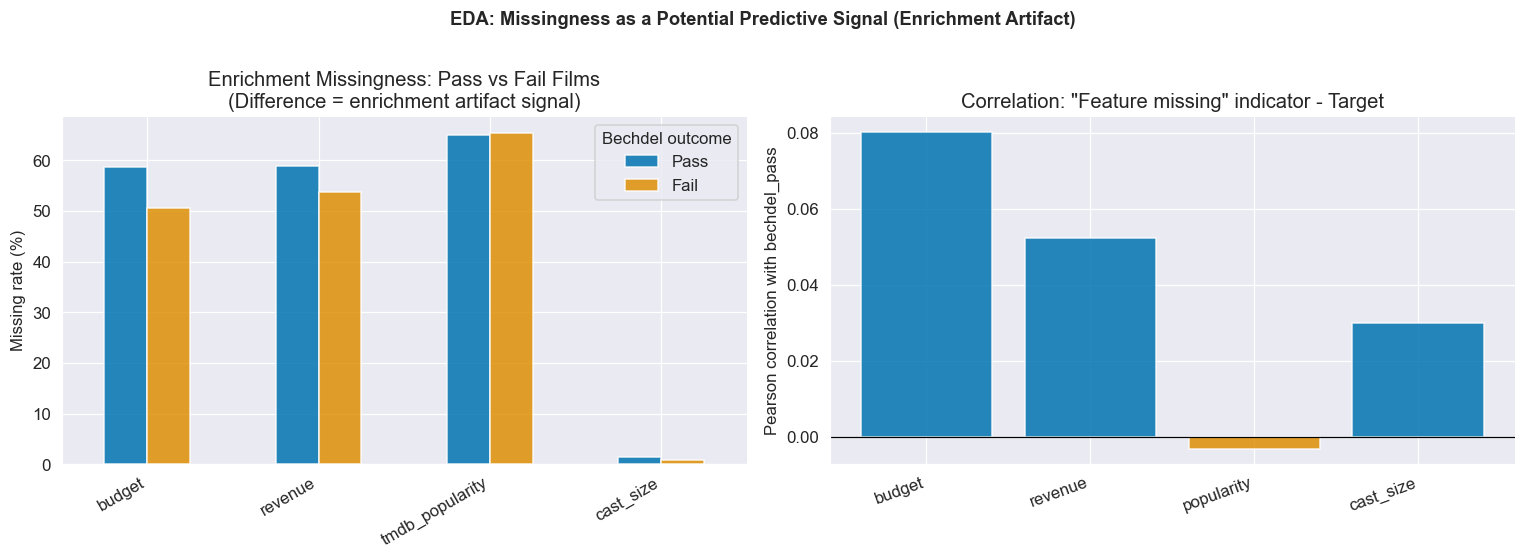

In [ ]:
# ── 6.2  Missingness analysis — does absence of enrichment data correlate with outcome?
#
# If films that PASS have lower missingness rates than films that FAIL, or vice versa,
# the model may learn to predict from data absence rather than data content.
# This is an enrichment artifact: which films happened to be included in the TMDb dataset.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

enrich_raw = [c for c in ['budget', 'revenue', 'tmdb_popularity', 'cast_size'] if c in df_raw2.columns]

# Missing rate by pass/fail
ax = axes[0]
miss_pass_df = pd.DataFrame({
    'Pass': [df_raw2.loc[df_raw2['bechdel_pass'] == 1, c].isna().mean() * 100 for c in enrich_raw],
    'Fail': [df_raw2.loc[df_raw2['bechdel_pass'] == 0, c].isna().mean() * 100 for c in enrich_raw],
}, index=enrich_raw)
miss_pass_df.plot.bar(ax=ax, color=[COLORS[0], COLORS[1]], alpha=0.85)
ax.set_ylabel('Missing rate (%)')
ax.set_title('Enrichment Missingness: Pass vs Fail Films\n'
             '(Difference = enrichment artifact signal)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Bechdel outcome')

# Correlation of missingness indicators with target
ax = axes[1]
enrich_eng = [c for c in ['log_budget', 'log_revenue', 'tmdb_popularity', 'log_cast_size'] if c in df.columns]
miss_corr = {c.replace('log_', '').replace('tmdb_', ''): df[c].isna().astype(int).corr(df['bechdel_pass'])
             for c in enrich_eng}
miss_corr_s = pd.Series(miss_corr)
ax.bar(miss_corr_s.index, miss_corr_s.values,
       color=[COLORS[0] if v >= 0 else COLORS[1] for v in miss_corr_s.values], alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Pearson correlation with bechdel_pass')
ax.set_title('Correlation: "Feature missing" indicator - Target')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')

plt.suptitle('EDA: Missingness as a Potential Predictive Signal (Enrichment Artifact)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

If these correlations are non-trivial (right graph), the model may learn from data absence.
We will test this formally in Section 9.

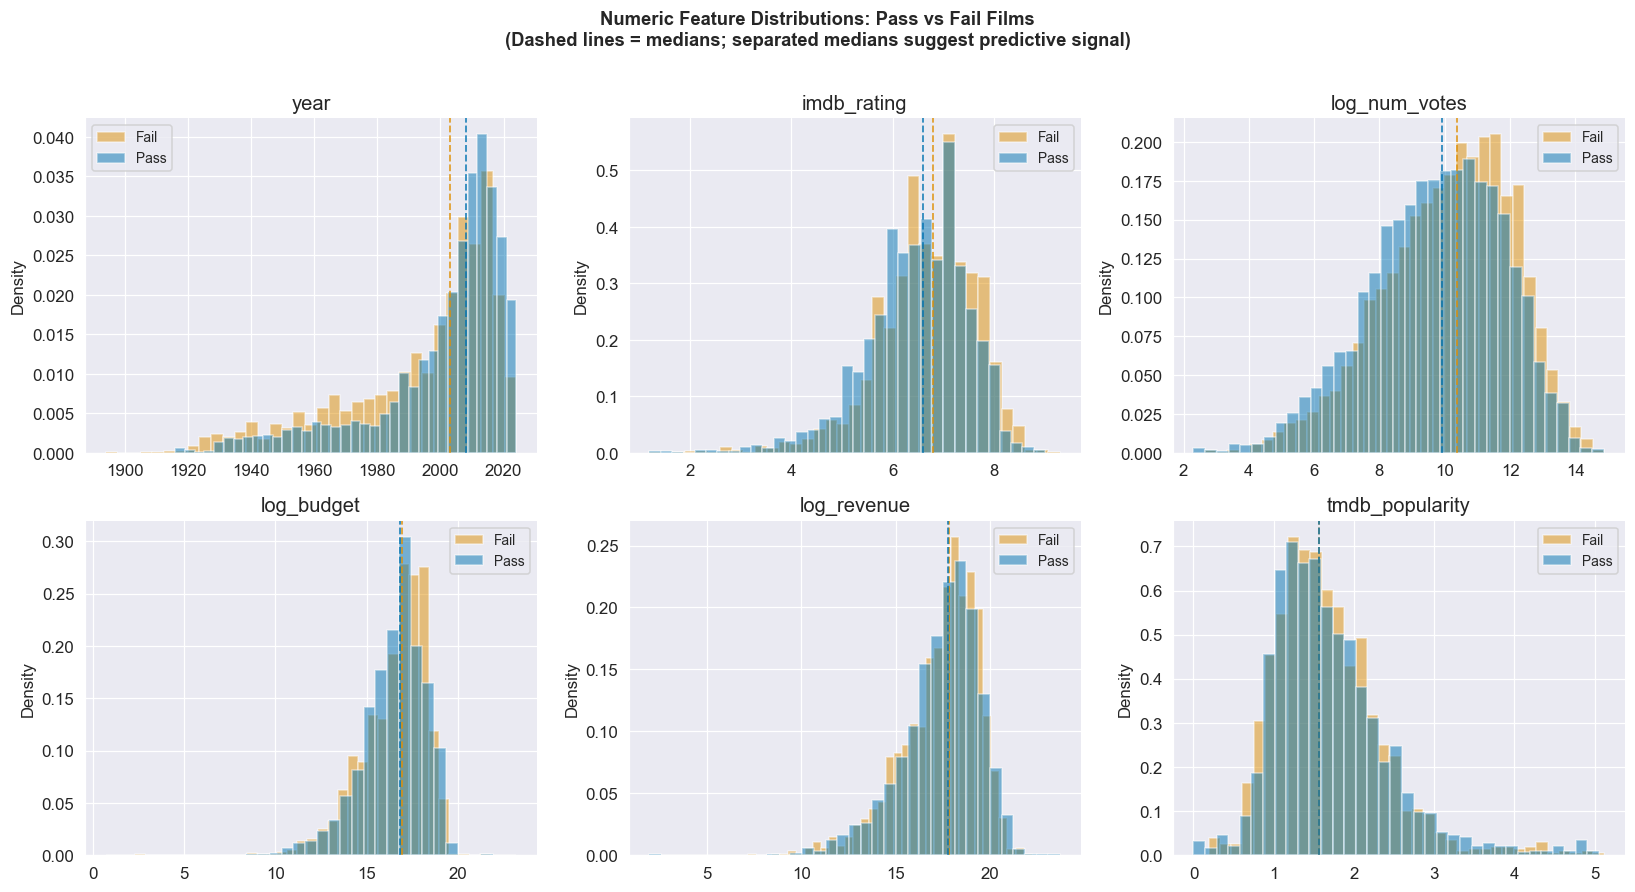

In [ ]:
# ── 6.3  Numeric feature distributions by Bechdel outcome ─────────────────
#
# Overlapping distributions → weak signal.  Well-separated → strong (possibly shortcut) signal.

show_cols = ['year', 'imdb_rating', 'log_num_votes', 'log_budget', 'log_revenue', 'tmdb_popularity']
show_cols = [c for c in show_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(show_cols):
    ax = axes[i]
    for val, label, color in [(0, 'Fail', COLORS[1]), (1, 'Pass', COLORS[0])]:
        data = df.loc[df['bechdel_pass'] == val, col].dropna()
        ax.hist(data, bins=35, alpha=0.5, label=label, color=color, density=True)
        ax.axvline(data.median(), linestyle='--', color=color, alpha=0.8, linewidth=1.2)
    ax.set_title(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Numeric Feature Distributions: Pass vs Fail Films\n'
             '(Dashed lines = medians; separated medians suggest predictive signal)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

To better understand how individual features relate to the target, we compared the distributions of several numerical variables between films that pass and fail the Bechdel Test.

The dashed vertical lines represent the median value for each class. Features whose distributions or medians differ noticeably between pass and fail films may carry useful predictive signal. Median is more robust to outliers and therefore provides a more reliable estimate of the typical value within each class.

Several patterns emerge:
- Films that pass the Bechdel Test tend to be more recent (`year`).
- Pass films exhibit slightly lower IMDb ratings and vote counts on average, although the differences are relatively modest.
- Revenue, budget, and popularity distributions show substantial overlap, suggesting that these features alone are not strong predictors but may still contribute useful information when combined with other variables.

no single feature cleanly separates the two classes. This suggests that Bechdel outcomes likely depend on multiple interacting signals rather than a single dominant variable, motivating the use of multivariate machine learning models.


## 7. Model Selection — Baseline (All Models on Training Split)

We evaluate all available classifiers under identical conditions:
- **Median imputation** was used for numerical features because several variables exhibited skewed distributions and extreme values. Compared to mean imputation, the median is more robust to outliers and therefore produces more stable imputations for movie metadata.
- **StandardScaler** was applied to numerical features to standardize feature magnitudes and improve optimization stability, particularly for models such as Logistic Regression.
- **One-hot encoding (OHE)** was used for the `decade` feature because decades are categorical rather than ordinal in the modeling context. OHE allows models to represent decade membership without imposing artificial linear relationships between decades.
- No missingness indicators
- No TF-IDF plot features in the initial baseline

Although we initially wanted to explore using TF-IDF representations of movie plot summaries, the plot-text coverage and quality were inconsistent across the dataset. Many entries were missing, extremely short, or contained only minimal metadata-like descriptions rather than meaningful narrative summaries.

Because sparse and low-quality text features can introduce noise and misleading signal, we chose to exclude TF-IDF from the baseline experiments.

**Model selection is based exclusively on CV ROC-AUC on the training split.**  
The held-out test set remains untouched until the final evaluation (section 12) to avoid optimistic bias and preserve a fair estimate of generalization performance.

### Why Fixed Hyperparameters?

The goal of this study is not to build the best possible Bechdel classifier. It is to compare
feature groups, imputation strategies, and signals against each other. For that, consistency
matters more than optimality. If each experiment used differently-tuned hyperparameters, any AUC
difference could be caused by the hyperparameter change rather than the feature change.
Fixed values isolate exactly what is being tested.

Proper hyperparameter tuning also requires nested cross-validation (outer loop for evaluation,
inner loop for search) to avoid optimistic bias. Without nesting, the tuned model's CV score leaks
information from the validation folds into model selection, inflating reported performance.
Given the project's focus on comparing experiments, the added complexity is not justified.

The chosen values are well-established robust defaults for tabular data:

| Model | Hyperparameter choice | Justification |
|-------|-----------------------|---------------|
| Logistic Regression | `max_iter=1000` | Ensures convergence on high-dimensional feature sets |
| Decision Tree | `max_depth=6` | Depth 6 gives ~64 leaf nodes — expressive without severe overfitting |
| Random Forest | 300 trees, `min_samples_leaf=2` | 300 trees stabilises variance; `min_samples_leaf=2` prevents single-sample leaves |
| XGBoost | 400 estimators, `lr=0.05` | Low learning rate + more rounds follows the shrinkage principle; a standard robust starting point |
| All classifiers | `class_weight="balanced"` | Adjusts loss contributions proportionally to class frequency, preventing the model from ignoring the minority class |


In [ ]:
print('=' * 75)
print('BASELINE: All models, median imputation, no TF-IDF')
print('=' * 75)
print(f'{"Experiment":<60} {"CV AUC":>10}  {"TestAUC":>8}  {"F1":>6}')
print('-' * 75)

model_keys = ['dummy', 'logreg', 'tree', 'rf'] + (['xgb'] if HAS_XGB2 else [])

baseline_results = {}
for mk in model_keys:
    res = run_experiment({
        'experiment_name': f'Baseline — {mk}',
        'model_key': mk,
        'imputation': 'median',
        'use_tfidf': False,
        'add_missingness': False,
        'drop_features': [],
        'ablation_type': 'baseline',
        'notes': 'Default median-imputed pipeline, all features',
    })
    if res:
        baseline_results[mk] = res

print('\nModel selection is based on CV ROC-AUC on the training split only.')

BASELINE: All models, median imputation, no TF-IDF
Experiment                                                       CV AUC   TestAUC      F1
---------------------------------------------------------------------------
  Baseline — dummy                                           CV=0.5000±0.0000  TestAUC=0.5000  F1=0.7315
  Baseline — logreg                                          CV=0.6751±0.0145  TestAUC=0.6892  F1=0.6670
  Baseline — tree                                            CV=0.6409±0.0099  TestAUC=0.6554  F1=0.7267
  Baseline — rf                                              CV=0.6643±0.0124  TestAUC=0.6753  F1=0.7106
  Baseline — xgb                                             CV=0.6783±0.0126  TestAUC=0.6842  F1=0.7194

Model selection is based on CV ROC-AUC on the training split only.


In [ ]:
# Select best non-dummy model based on CV AUC
non_dummy = {k: v for k, v in baseline_results.items() if k != 'dummy'}
BEST_MODEL = max(non_dummy, key=lambda k: non_dummy[k]['cv_mean'])
BEST_RESULT = baseline_results[BEST_MODEL]

print(f'Best model (by CV ROC-AUC): {BEST_MODEL.upper()}')
print(f'  CV  ROC-AUC:  {BEST_RESULT["cv_mean"]:.4f} ± {BEST_RESULT["cv_std"]:.4f}')
print(f'  Test ROC-AUC: {BEST_RESULT["roc_auc"]:.4f}')
print(f'  Test F1:      {BEST_RESULT["f1"]:.4f}')
print(f'\nAll ablation experiments will use: {BEST_MODEL.upper()}')

Best model (by CV ROC-AUC): XGB
  CV  ROC-AUC:  0.6783 ± 0.0126
  Test ROC-AUC: 0.6842
  Test F1:      0.7194

All ablation experiments will use: XGB


## 8. Imputation Strategy Experiments

~50–78% of TMDb-derived features are missing. The choice of imputation strategy can affect model performance, especially for tree-based models. We test three strategies on the best model.

| Strategy | Description | Expected effect |
|----------|-------------|----------------|
| `median` | Replace missing values with the column median | Robust to outliers (default) |
| `mean` | Replace with column mean | Sensitive to outliers in budget/revenue |
| `most_frequent` | Replace with the most common value | Mainly useful for sparse/categorical-like numerics |

**Leakage note:** All imputation statistics are computed **inside the CV fold** on training data only, never on the full dataset.

In [ ]:
print('=' * 75)
print(f'IMPUTATION EXPERIMENTS  (model: {BEST_MODEL.upper()})')
print('=' * 75)
print(f'{"Experiment":<60} {"CV AUC":>10}  {"TestAUC":>8}  {"F1":>6}')
print('-' * 75)

imputation_results = {}
for strategy, label in [
    ('median',        'Median imputation (default)'),
    ('mean',          'Mean imputation'),
    ('most_frequent', 'Most-frequent imputation'),
]:
    res = run_experiment({
        'experiment_name': f'Imputation — {strategy}',
        'model_key': BEST_MODEL,
        'imputation': strategy,
        'use_tfidf': False,
        'add_missingness': False,
        'drop_features': [],
        'ablation_type': 'imputation',
        'notes': label,
    })
    if res:
        imputation_results[strategy] = res

print('\nInterpretation guide:')
print('  Large differences between strategies → imputation choice has meaningful impact.')
print('  Small differences → imputed values are not heavily relied upon (robust to choice).')

IMPUTATION EXPERIMENTS  (model: XGB)
Experiment                                                       CV AUC   TestAUC      F1
---------------------------------------------------------------------------
  Imputation — median                                        CV=0.6783±0.0126  TestAUC=0.6842  F1=0.7194
  Imputation — mean                                          CV=0.6767±0.0113  TestAUC=0.6837  F1=0.7271
  Imputation — most_frequent                                 CV=0.6781±0.0134  TestAUC=0.6885  F1=0.7282

Interpretation guide:
  Large differences between strategies → imputation choice has meaningful impact.
  Small differences → imputed values are not heavily relied upon (robust to choice).


We compared several simple imputation strategies to evaluate how sensitive the model was to missing value handling.

Across median, mean, and most frequent imputation, performance differences remained relatively small on both cross-validation and held-out test metrics. This suggests that the overall predictive signal is reasonably robust to the specific imputation strategy used.

Interestingly, the most frequent strategy produced slightly stronger final metrics, although the differences are modest and not large enough to fundamentally change model behavior.

These results indicate that, within simple imputation approaches, preprocessing choice has less impact on performance than broader feature-group structure and dataset characteristics.

## 9. Missingness-as-Signal Experiment

**Research question:** Does the *absence* of enrichment data itself predict Bechdel outcomes?

If a film is absent from TMDb (missing budget, revenue, popularity), that absence may correlate with certain film types — e.g., older, lower-budget, or non-English-language films. If those film types have systematically different Bechdel pass rates, the model can learn to predict from data absence rather than content.

We test this by adding five binary indicator features:
- `budget_missing`, `revenue_missing`, `popularity_missing`, `cast_size_missing`, `plot_missing`

**Interpretation:**
- If adding indicators **improves AUC** → missingness carries signal → enrichment artifact present.
- If adding indicators has **no effect** → missingness is ignorable noise.
- If adding indicators **hurts performance** → indicators are confusing the model.

In [ ]:
print('=' * 75)
print(f'MISSINGNESS-AS-SIGNAL EXPERIMENT  (model: {BEST_MODEL.upper()})')
print('=' * 75)
print(f'{"Experiment":<60} {"CV AUC":>10}  {"TestAUC":>8}  {"F1":>6}')
print('-' * 75)

miss_baseline_res = run_experiment({
    'experiment_name': 'Missingness — No indicators',
    'model_key': BEST_MODEL,
    'imputation': 'median',
    'use_tfidf': False,
    'add_missingness': False,
    'drop_features': [],
    'ablation_type': 'missingness',
    'notes': 'Baseline without missingness indicator features',
})

miss_indicators_res = run_experiment({
    'experiment_name': 'Missingness — With indicators',
    'model_key': BEST_MODEL,
    'imputation': 'median',
    'use_tfidf': False,
    'add_missingness': True,
    'drop_features': [],
    'ablation_type': 'missingness',
    'notes': 'With budget_missing, revenue_missing, popularity_missing, cast_size_missing, plot_missing',
})

delta_auc = miss_indicators_res['roc_auc'] - miss_baseline_res['roc_auc']
print(f'\nDelta Test AUC (indicators - baseline): {delta_auc:+.4f}')

MISSINGNESS-AS-SIGNAL EXPERIMENT  (model: XGB)
Experiment                                                       CV AUC   TestAUC      F1
---------------------------------------------------------------------------
  Missingness — No indicators                                CV=0.6783±0.0126  TestAUC=0.6842  F1=0.7194
  Missingness — With indicators                              CV=0.6778±0.0140  TestAUC=0.6861  F1=0.7311

Delta Test AUC (indicators - baseline): +0.0019


Adding missingness indicator features produced only a very small improvement in test ROC-AUC. This suggests that, although enrichment missingness exhibits some correlation with the target, the model does not appear to rely heavily on missingness patterns themselves for prediction.

In other words, the presence or absence of enrichment data contributes relatively little unique predictive information beyond the existing feature set.

## 10. Ablation Experiments

We systematically remove feature groups to measure each group's contribution to predictive performance. All ablations use:
- The best-performing model selected in Section 7
- Median imputation
- No TF-IDF (clean comparison with the reference baseline)
- The same fixed train/test split

The AUC drop from the full-feature reference tells us how much each feature group contributes.

| Ablation | Features removed | Research question |
|----------|-----------------|-------------------|
| Genre | All `genre_*` | Is the model a genre classifier? |
| Popularity/Success | `imdb_rating`, `log_num_votes`, `log_budget`, `log_revenue`, `tmdb_popularity` | Does the model use commercial success as a proxy? |
| Temporal | `year`, `decade` | Is the model learning historical trends instead of content? |
| TMDb enrichment | All TMDb-only features | Does enrichment coverage introduce dataset-coverage shortcuts? |
| Plot/Text | TF-IDF experiment — best model with vs without plot TF-IDF | Does semantic content drive predictions? |

In [ ]:
print('=' * 75)
print(f'ABLATION EXPERIMENTS  (model: {BEST_MODEL.upper()}, imputation: median)')
print('=' * 75)
print(f'{"Experiment":<60} {"CV AUC":>10}  {"TestAUC":>8}  {"F1":>6}')
print('-' * 75)

ablation_configs = [
    {
        'experiment_name': 'Ablation — Full features (reference)',
        'model_key': BEST_MODEL, 'imputation': 'median',
        'use_tfidf': False, 'add_missingness': False, 'drop_features': [],
        'ablation_type': 'full_reference',
        'notes': 'All features; reference for ablation comparisons',
    },
    {
        'experiment_name': 'Ablation — No genre features',
        'model_key': BEST_MODEL, 'imputation': 'median',
        'use_tfidf': False, 'add_missingness': False,
        'drop_features': GENRE_FEATURES,
        'ablation_type': 'genre',
        'notes': 'Remove all genre_* to test genre-stereotype shortcut reliance',
    },
    {
        'experiment_name': 'Ablation — No popularity/success features',
        'model_key': BEST_MODEL, 'imputation': 'median',
        'use_tfidf': False, 'add_missingness': False,
        'drop_features': POPULARITY_FEATURES,
        'ablation_type': 'popularity',
        'notes': 'Remove imdb_rating, log_num_votes, log_budget, log_revenue, tmdb_popularity',
    },
    {
        'experiment_name': 'Ablation — No temporal features',
        'model_key': BEST_MODEL, 'imputation': 'median',
        'use_tfidf': False, 'add_missingness': False,
        'drop_features': TEMPORAL_FEATURES,
        'ablation_type': 'temporal',
        'notes': 'Remove year, decade to isolate temporal bias contribution',
    },
    {
        'experiment_name': 'Ablation — No TMDb enrichment features',
        'model_key': BEST_MODEL, 'imputation': 'median',
        'use_tfidf': False, 'add_missingness': False,
        'drop_features': TMDB_ENRICHMENT_FEATURES,
        'ablation_type': 'tmdb_enrichment',
        'notes': 'Remove all TMDb-sourced features: budget, revenue, popularity, cast_size, has_female_director',
    },
    {
        'experiment_name': 'Ablation — No runtime (log_runtime)',
        'model_key': BEST_MODEL, 'imputation': 'median',
        'use_tfidf': False, 'add_missingness': False,
        'drop_features': ['log_runtime'],
        'ablation_type': 'runtime',
        'notes': 'Remove log_runtime to test how much film length matters',
    },
    {
        'experiment_name': 'Ablation — No has_female_director',
        'model_key': BEST_MODEL, 'imputation': 'median',
        'use_tfidf': False, 'add_missingness': False,
        'drop_features': ['has_female_director'],
        'ablation_type': 'female_director',
        'notes': 'Remove has_female_director to isolate behind-camera representation signal',
    },
]

ablation_results = {}
for cfg in ablation_configs:
    res = run_experiment(cfg)
    if res:
        ablation_results[cfg["ablation_type"]] = res


ABLATION EXPERIMENTS  (model: XGB, imputation: median)
Experiment                                                       CV AUC   TestAUC      F1
---------------------------------------------------------------------------
  Ablation — Full features (reference)                       CV=0.6783±0.0126  TestAUC=0.6842  F1=0.7194
  Ablation — No genre features                               CV=0.6289±0.0111  TestAUC=0.6360  F1=0.6923
  Ablation — No popularity/success features                  CV=0.6629±0.0161  TestAUC=0.6747  F1=0.7153
  Ablation — No temporal features                            CV=0.6729±0.0141  TestAUC=0.6759  F1=0.7195
  Ablation — No TMDb enrichment features                     CV=0.6562±0.0141  TestAUC=0.6728  F1=0.7253
  Ablation — No runtime (log_runtime)                        CV=0.6754±0.0132  TestAUC=0.6863  F1=0.7269
  Ablation — No has_female_director                          CV=0.6638±0.0148  TestAUC=0.6735  F1=0.7249


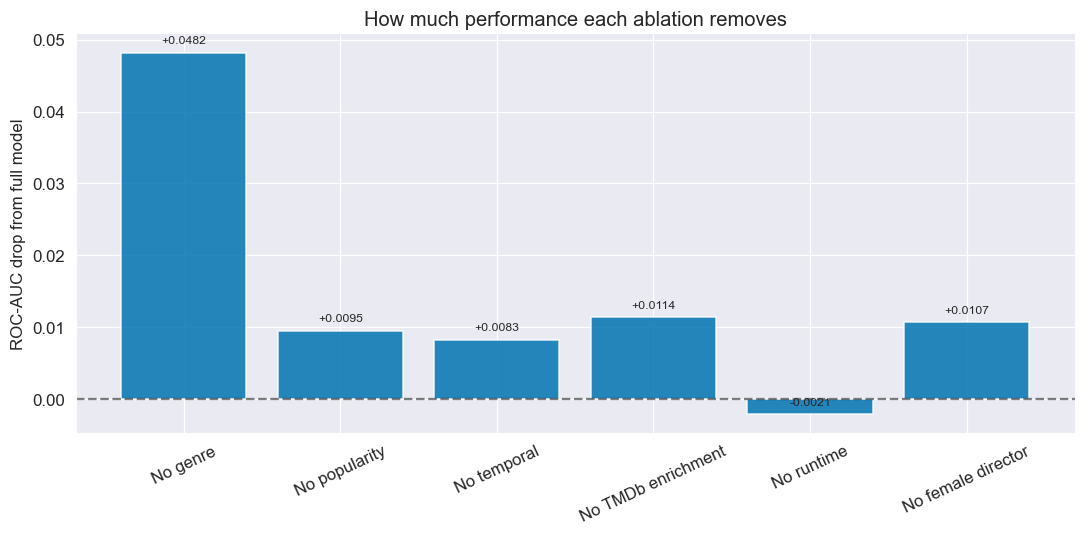

In [ ]:
# ── AUC Drop from Full Model ──────────────────────────────────────────────
if 'full_reference' in ablation_results:
    full_auc = ablation_results['full_reference']['roc_auc']

    compare_order = [
        ('genre', 'No genre'),
        ('popularity', 'No popularity'),
        ('temporal', 'No temporal'),
        ('tmdb_enrichment', 'No TMDb enrichment'),
        ('runtime', 'No runtime'),
        ('female_director', 'No female director'),
    ]

    compare_keys = [k for k, _ in compare_order if k in ablation_results]
    compare_labels = [lbl for k, lbl in compare_order if k in ablation_results]
    auc_drops = [full_auc - ablation_results[k]['roc_auc'] for k in compare_keys]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(compare_labels, auc_drops, alpha=0.85)
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_ylabel('ROC-AUC drop from full model')
    ax.set_title('How much performance each ablation removes')
    ax.tick_params(axis='x', rotation=25)

    for bar, drop in zip(bars, auc_drops):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            drop + 0.001,
            f'{drop:+.4f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

    plt.tight_layout()
    plt.show()

## 11. Results Comparison Tables

We aggregate all experiment results into a single table for comparison.

**Columns:**
- `cv_mean / cv_std` — cross-validated ROC-AUC on the training split (used for model selection)
- `roc_auc` — test-set ROC-AUC (final reporting only)
- `f1` — test-set F1 score
- `avg_precision` — test-set average precision (area under PR curve)

In [ ]:
# ── Complete results table ────────────────────────────────────────────────
results_df = pd.DataFrame(ALL_RESULTS)

display_cols = [
    'experiment_name', 'model_name', 'imputation_method', 'ablation_type',
    'cv_mean', 'cv_std', 'accuracy', 'precision', 'recall', 'f1',
    'roc_auc', 'avg_precision', 'notes'
]
display_cols = [c for c in display_cols if c in results_df.columns]

print(f'Total experiments logged: {len(results_df)}')
results_df[display_cols].style.background_gradient(subset=['roc_auc', 'f1'], cmap='RdYlGn')


Total experiments logged: 17


,experiment_name,model_name,imputation_method,ablation_type,cv_mean,cv_std,accuracy,precision,recall,f1,roc_auc,avg_precision,notes
0,Baseline — dummy,dummy,median,baseline,0.500000,0.000000,0.576600,0.576600,1.000000,0.731500,0.500000,0.576600,"Default median-imputed pipeline, all features"
1,Baseline — logreg,logreg,median,baseline,0.675100,0.014500,0.637300,0.708800,0.629800,0.667000,0.689200,0.722000,"Default median-imputed pipeline, all features"
2,Baseline — tree,tree,median,baseline,0.640900,0.009900,0.630100,0.633100,0.852800,0.726700,0.655400,0.695200,"Default median-imputed pipeline, all features"
3,Baseline — rf,rf,median,baseline,0.664300,0.012400,0.645100,0.670600,0.755600,0.710600,0.675300,0.709800,"Default median-imputed pipeline, all features"
4,Baseline — xgb,xgb,median,baseline,0.678300,0.012600,0.648100,0.665900,0.782300,0.719400,0.684200,0.716200,"Default median-imputed pipeline, all features"
5,Imputation — median,xgb,median,imputation,0.678300,0.012600,0.648100,0.665900,0.782300,0.719400,0.684200,0.716200,Median imputation (default)
6,Imputation — mean,xgb,mean,imputation,0.676700,0.011300,0.654800,0.668200,0.797500,0.727100,0.683700,0.718500,Mean imputation
7,Imputation — most_frequent,xgb,most_frequent,imputation,0.678100,0.013400,0.659000,0.673700,0.792100,0.728200,0.688500,0.723900,Most-frequent imputation
8,Missingness — No indicators,xgb,median,missingness,0.678300,0.012600,0.648100,0.665900,0.782300,0.719400,0.684200,0.716200,Baseline without missingness indicator features
9,Missingness — With indicators,xgb,median,missingness,0.677800,0.014000,0.661000,0.673700,0.799300,0.731100,0.686100,0.720200,"With budget_missing, revenue_missing, popularity_missing, cast_size_missing, plot_missing"


In [ ]:
# ── Ablation summary: AUC drop and % signal retained ─────────────────────
abl_types = ['full_reference', 'genre', 'popularity', 'temporal', 'tmdb_enrichment', 'runtime', 'female_director']
abl_df = results_df[results_df['ablation_type'].isin(abl_types)].copy()

if 'full_reference' in abl_df['ablation_type'].values:
    ref_auc = abl_df.loc[abl_df['ablation_type'] == 'full_reference', 'roc_auc'].values[0]
    abl_df['auc_drop'] = (ref_auc - abl_df['roc_auc']).round(4)
    total_signal = ref_auc - 0.5
    abl_df['signal_retained_pct'] = ((abl_df['roc_auc'] - 0.5) / total_signal * 100).round(1)
    abl_df['signal_lost_pct'] = (abl_df['auc_drop'] / total_signal * 100).round(1)

    print('=' * 65)
    print('ABLATION SUMMARY')
    print(f'Reference (full features): Test AUC = {ref_auc:.4f}')
    print(f'Chance level:              Test AUC = 0.5000')
    print(f'Total signal above chance: {total_signal:.4f}')
    print('=' * 65)

    summary_cols = ['experiment_name', 'roc_auc', 'auc_drop', 'signal_lost_pct', 'signal_retained_pct', 'f1']
    summary_cols = [c for c in summary_cols if c in abl_df.columns]
    print(abl_df[summary_cols].to_string(index=False))
    print()
    print('signal_lost_pct: how much of the predictive advantage above chance is lost when this group is removed.')
    print('signal_retained_pct: how much of predictive advantage remains without this group.')

ABLATION SUMMARY
Reference (full features): Test AUC = 0.6842
Chance level:              Test AUC = 0.5000
Total signal above chance: 0.1842
                          experiment_name  roc_auc  auc_drop  signal_lost_pct  signal_retained_pct     f1
     Ablation — Full features (reference)   0.6842    0.0000              0.0                100.0 0.7194
             Ablation — No genre features   0.6360    0.0482             26.2                 73.8 0.6923
Ablation — No popularity/success features   0.6747    0.0095              5.2                 94.8 0.7153
          Ablation — No temporal features   0.6759    0.0083              4.5                 95.5 0.7195
   Ablation — No TMDb enrichment features   0.6728    0.0114              6.2                 93.8 0.7253
      Ablation — No runtime (log_runtime)   0.6863   -0.0021             -1.1                101.1 0.7269
        Ablation — No has_female_director   0.6735    0.0107              5.8                 94.2 0.7249

signal_los

Genre is the single strongest feature group, removing approximately 26% of the model’s predictive signal above chance. However, roughly 74% of the signal remains even after removing all genre-related features, indicating that the classifier is not simply acting as a genre predictor.

Interestingly, removing `runtime` very slightly improved performance rather than reducing it, resulting in more than 100% signal retention relative to the full model. This suggests that runtime contributes little useful predictive information and may instead introduce weak noise or unstable patterns into the learning process.

Overall, predictive performance remains relatively stable after removing any single feature group. This suggests that the model relies on multiple interacting signals rather than one dominant shortcut feature. While genre contributes substantial predictive power, the classifier also learns from temporal, enrichment-related, and representation-related information.

## 12. Visualisations & Interpretation

Each visualisation is paired with an explanation of what it shows and which experiment it supports.

| # | Plot | Purpose |
|---|------|---------|
| 12.1 | Model comparison bar chart | Baseline model selection |
| 12.2 | ROC curves — all baseline models | AUC comparison across models |
| 12.3 | Confusion matrices (raw + normalised) | Error pattern for best model |
| 12.4 | Precision-Recall curves | Performance at varying thresholds |
| 12.5 | Permutation importance | Which features drive predictions |
| 12.6 | SHAP summary plot | Feature effect direction and magnitude |
| 12.7 | Calibration curves | Are predicted probabilities reliable? |
| 12.8 | Learning curve | Overfitting / data efficiency |
| 12.9 | Ablation comparison chart | Feature group contribution |
| 12.10 | Imputation strategy comparison | Sensitivity to imputation choice |
| 12.11 | Error analysis — false positive/negative patterns | Where the model fails |
| 12.12 | Genre distribution in error types | Is genre the source of errors? |

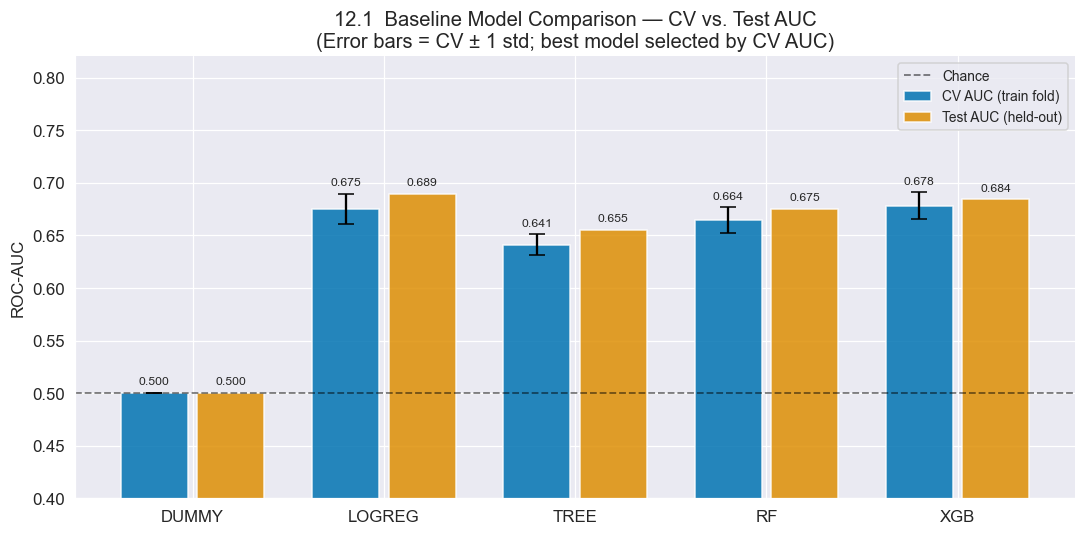

In [ ]:
# ── 12.1  Model comparison bar chart ─────────────────────────────────────
# Purpose: Summarise baseline model performance. Cross-validated AUC on
# training data (used for selection) vs. test AUC (held-out reporting).
# A small gap between CV AUC and test AUC indicates no over-fitting.

fig, ax = plt.subplots(figsize=(10, 5))

model_names = list(baseline_results.keys())
cv_aucs   = [baseline_results[m]['cv_mean'] for m in model_names]
test_aucs = [baseline_results[m]['roc_auc']  for m in model_names]
cv_stds   = [baseline_results[m]['cv_std']   for m in model_names]

x = np.arange(len(model_names))
ax.bar(x - 0.2, cv_aucs,   0.35, label='CV AUC (train fold)',
       color=COLORS[0], alpha=0.85, yerr=cv_stds, capsize=5)
ax.bar(x + 0.2, test_aucs, 0.35, label='Test AUC (held-out)',
       color=COLORS[1], alpha=0.85)
ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, linewidth=1.2, label='Chance')
ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in model_names])
ax.set_ylabel('ROC-AUC')
ax.set_title('12.1  Baseline Model Comparison — CV vs. Test AUC\n'
             '(Error bars = CV ± 1 std; best model selected by CV AUC)')
ax.legend(fontsize=9)
ax.set_ylim(0.40, 0.82)
for xi, (cv_a, te_a) in enumerate(zip(cv_aucs, test_aucs)):
    ax.text(xi - 0.2, cv_a + cv_stds[xi] + 0.008, f'{cv_a:.3f}', ha='center', fontsize=8)
    ax.text(xi + 0.2, te_a + 0.008, f'{te_a:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

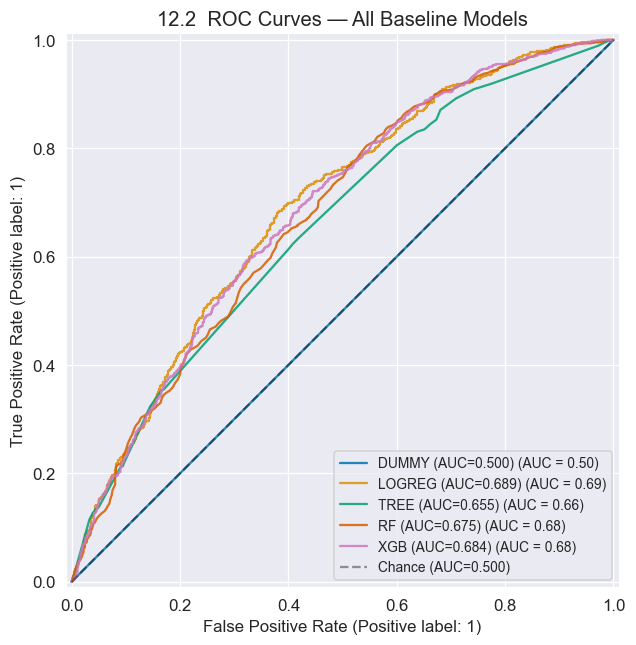

In [ ]:
# ── 12.2  ROC curves — all baseline models ───────────────────────────────
# Purpose: Compare the full ROC curve shape across models. A model with a higher
# AUC is better on average, but the curve shape reveals where each model excels
# (low FPR regime vs high recall regime).

fig, ax = plt.subplots(figsize=(7, 6))

for mk, res in baseline_results.items():
    RocCurveDisplay.from_predictions(
        y_test, res['_y_prob'],
        name=f'{mk.upper()} (AUC={res["roc_auc"]:.3f})',
        ax=ax, alpha=0.85,
    )
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Chance (AUC=0.500)')
ax.set_title('12.2  ROC Curves — All Baseline Models')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

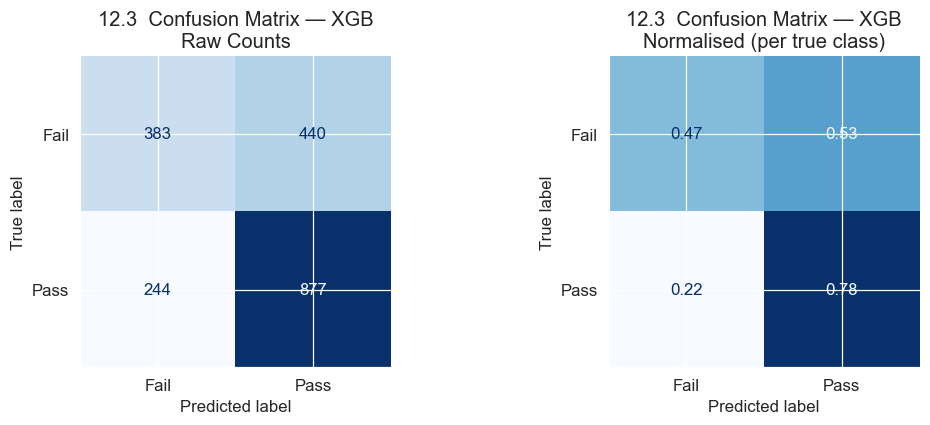

Interpretation:
  Top-left (TN): predicted Fail, actually Fail
  Bottom-right (TP): predicted Pass, actually Pass
  Top-right (FP): predicted Pass, actually Fail  ← false alarm
  Bottom-left (FN): predicted Fail, actually Pass ← missed detection


In [ ]:
# ── 12.3  Confusion matrices ──────────────────────────────────────────────
# Purpose: Understand the error structure of the best model.
# The normalised matrix shows per-class recall (sensitivity/specificity).
# The raw matrix shows actual counts, useful for error analysis.

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, normalize, title_suffix in zip(
    axes,
    [None, 'true'],
    ['Raw Counts', 'Normalised (per true class)']
):
    ConfusionMatrixDisplay.from_predictions(
        y_test, BEST_RESULT['_y_pred'],
        display_labels=['Fail', 'Pass'],
        normalize=normalize,
        colorbar=False, ax=ax, cmap='Blues',
    )
    ax.set_title(f'12.3  Confusion Matrix — {BEST_MODEL.upper()}\n{title_suffix}')

plt.tight_layout()
plt.show()

Interpretation:
  - Top-left (TN): predicted Fail, actually Fail
  - Bottom-right (TP): predicted Pass, actually Pass
  - Top-right (FP): predicted Pass, actually Fail  ← false alarm
  - Bottom-left (FN): predicted Fail, actually Pass ← missed detection

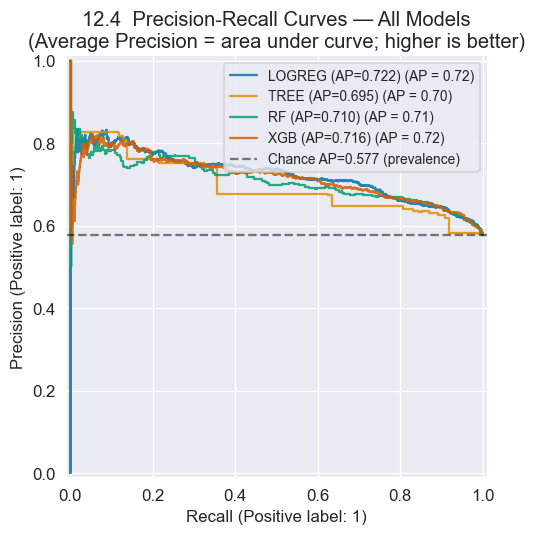

In [ ]:
# ── 12.4  Precision-Recall curves ─────────────────────────────────────────
# Purpose: Especially informative for imbalanced datasets. The PR curve shows
# the precision-recall trade-off at all classification thresholds.
# Average Precision (AP) summarises the curve area — higher is better.
# The horizontal dashed line is the naive classifier's precision (= prevalence).

fig, ax = plt.subplots(figsize=(7, 5))

for mk, res in baseline_results.items():
    if mk == 'dummy':
        continue
    PrecisionRecallDisplay.from_predictions(
        y_test, res['_y_prob'],
        name=f'{mk.upper()} (AP={res["avg_precision"]:.3f})',
        ax=ax, alpha=0.85,
    )

prevalence = y_test.mean()
ax.axhline(prevalence, color='black', linestyle='--', alpha=0.5,
           label=f'Chance AP={prevalence:.3f} (prevalence)')
ax.set_title('12.4  Precision-Recall Curves — All Models\n'
             '(Average Precision = area under curve; higher is better)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

Computing permutation importance on test set (10 repeats)...


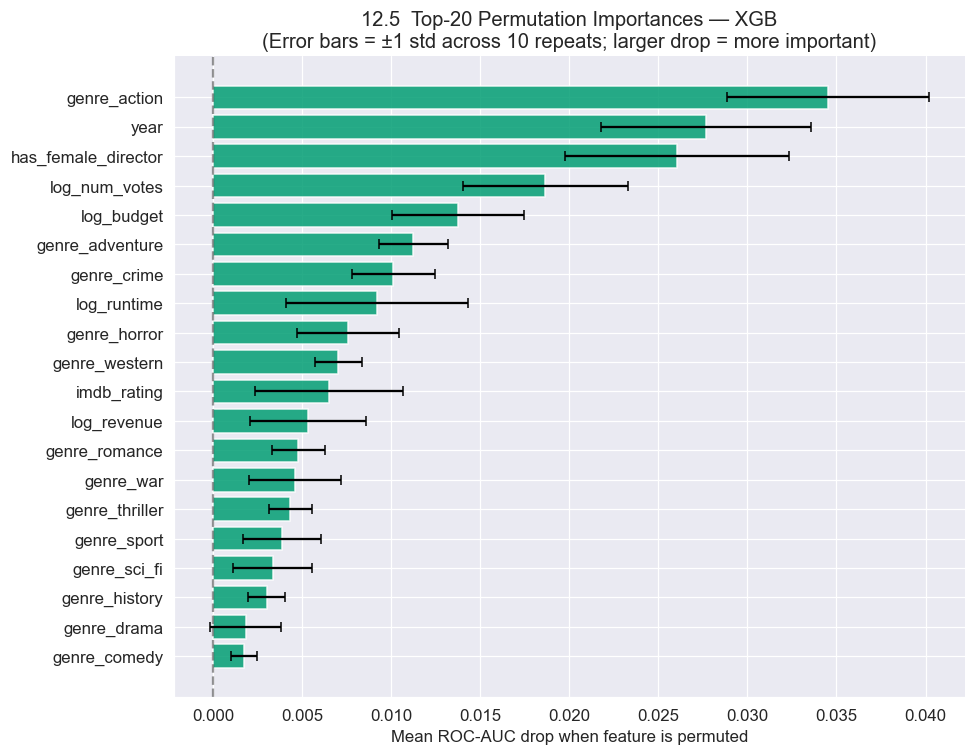


Top 10 features by permutation importance:
  genre_action                        +0.0345 ± 0.0057
  year                                +0.0277 ± 0.0059
  has_female_director                 +0.0260 ± 0.0063
  log_num_votes                       +0.0187 ± 0.0046
  log_budget                          +0.0137 ± 0.0037
  genre_adventure                     +0.0113 ± 0.0019
  genre_crime                         +0.0101 ± 0.0023
  log_runtime                         +0.0092 ± 0.0051
  genre_horror                        +0.0076 ± 0.0029
  genre_western                       +0.0070 ± 0.0013


In [ ]:
# ── 12.5  Permutation importance ─────────────────────────────────────────
# Purpose: Identify which features drive predictions in the best model.
# Permutation importance shuffles one feature at a time and measures the
# AUC drop on the test set. Features with high importance are relied on heavily.
# Features with near-zero importance can be removed without harm.
#
# This directly addresses: is the model relying on genre, year, popularity, etc?

best_pipeline = BEST_RESULT['_pipeline']
best_X_te     = BEST_RESULT['_X_te']

print('Computing permutation importance on test set (10 repeats)...')
perm = perm_imp(
    best_pipeline, best_X_te, y_test,
    n_repeats=10, random_state=RANDOM_STATE, scoring='roc_auc', n_jobs=-1
)

feat_names = list(best_X_te.columns)
sorted_idx = np.argsort(perm.importances_mean)[-20:]  # top 20

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(
    np.array(feat_names)[sorted_idx],
    perm.importances_mean[sorted_idx],
    xerr=perm.importances_std[sorted_idx],
    capsize=3, color=COLORS[2], alpha=0.85,
)
ax.axvline(0, color='black', linestyle='--', alpha=0.4)
ax.set_xlabel('Mean ROC-AUC drop when feature is permuted')
ax.set_title(f'12.5  Top-20 Permutation Importances — {BEST_MODEL.upper()}\n'
             '(Error bars = ±1 std across 10 repeats; larger drop = more important)')
plt.tight_layout()
plt.show()

print('\nTop 10 features by permutation importance:')
for i in sorted_idx[::-1][:10]:
    print(f'  {feat_names[i]:<35} {perm.importances_mean[i]:+.4f} ± {perm.importances_std[i]:.4f}')

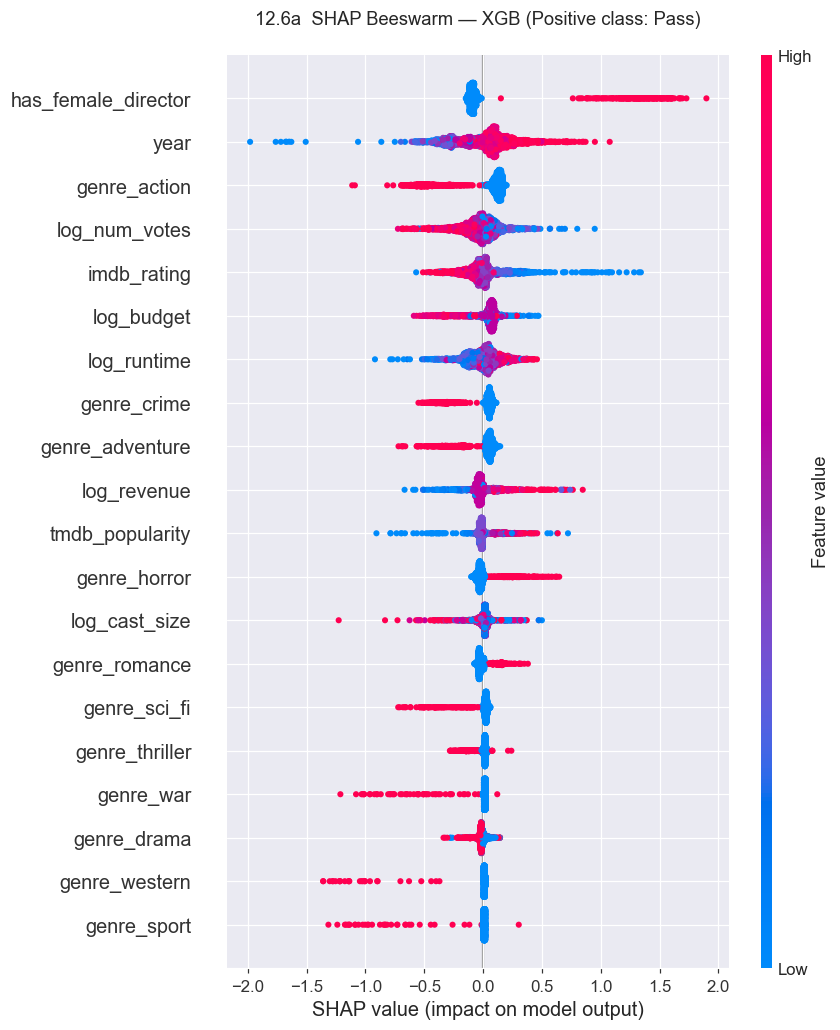

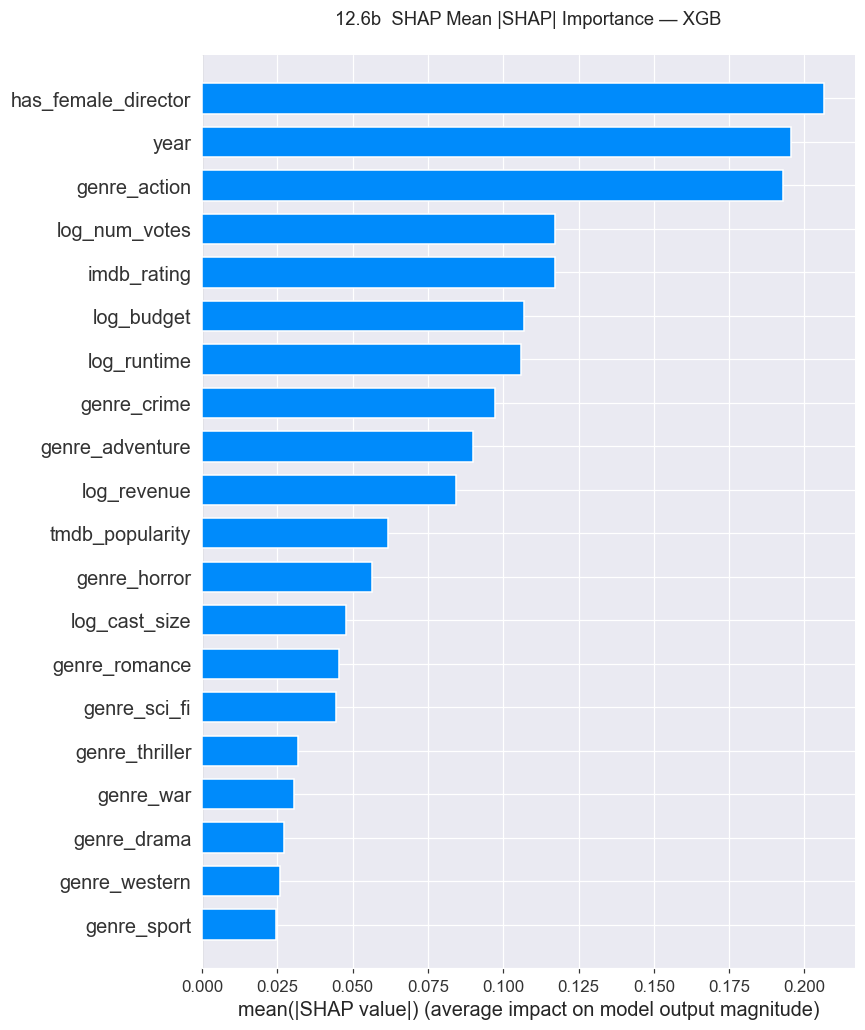

In [ ]:
# ── 12.6  SHAP Summary Plot ───────────────────────────────────────────────
# Purpose: SHAP (SHapley Additive exPlanations) shows not just which features
# matter but also the DIRECTION and MAGNITUDE of their effect on each prediction.
# Red points = high feature value; blue = low feature value.
# A wide horizontal spread means the feature has large impact on predictions.

if HAS_SHAP and BEST_MODEL in ('xgb', 'rf', 'tree'):
    try:
        preprocessor_step = best_pipeline.named_steps['preprocess']
        clf_step = best_pipeline.named_steps['clf']

        X_te_transformed = preprocessor_step.transform(best_X_te)

        try:
            shap_feat_names = list(preprocessor_step.get_feature_names_out())
        except Exception:
            shap_feat_names = [f'f{i}' for i in range(X_te_transformed.shape[1])]

        explainer = shap.TreeExplainer(clf_step)
        shap_values = explainer.shap_values(X_te_transformed)

        # For binary classification, some versions return list [neg_class, pos_class]
        if isinstance(shap_values, list):
            shap_vals = shap_values[1]
        else:
            shap_vals = shap_values

        shap.summary_plot(shap_vals, X_te_transformed,
                          feature_names=shap_feat_names, max_display=20, show=False)
        plt.title(f'12.6a  SHAP Beeswarm — {BEST_MODEL.upper()} (Positive class: Pass)',
                  pad=20, fontsize=12)
        plt.tight_layout()
        plt.show()

        shap.summary_plot(shap_vals, X_te_transformed,
                          feature_names=shap_feat_names, max_display=20,
                          plot_type='bar', show=False)
        plt.title(f'12.6b  SHAP Mean |SHAP| Importance — {BEST_MODEL.upper()}', pad=20, fontsize=12)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f'SHAP plot failed: {e}')
        print('The Dense+TF-IDF union transformer may produce a format SHAP cannot handle directly.')
elif not HAS_SHAP:
    print('Install SHAP to enable these plots:  pip install shap')
else:
    print(f'SHAP TreeExplainer not applicable for: {BEST_MODEL}')

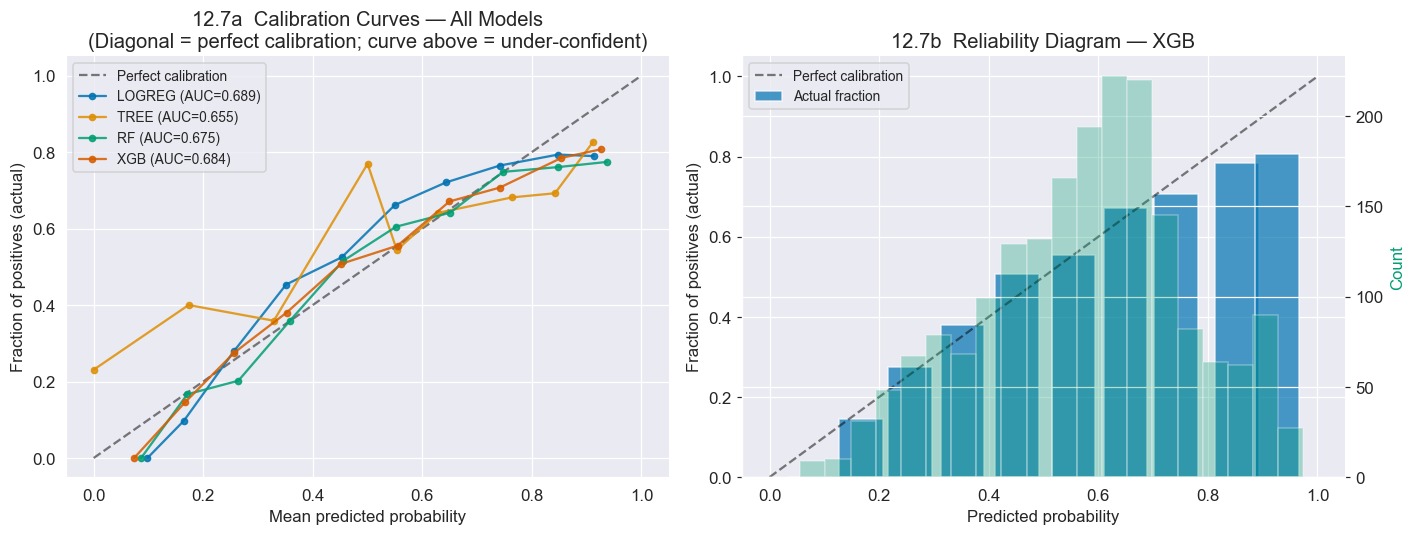

In [ ]:
# ── 12.7  Calibration Curves ──────────────────────────────────────────────
# Purpose: Check whether predicted probabilities are meaningful.
# A well-calibrated model produces probabilities that reflect the actual frequency
# of positive outcomes — e.g., a 70% prediction means ~70% of such cases are positive.
# Poor calibration matters if predictions are used for ranking or threshold decisions.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
for mk, res in baseline_results.items():
    if mk == 'dummy':
        continue
    frac_pos, mean_pred = calibration_curve(y_test, res['_y_prob'], n_bins=10)
    ax.plot(mean_pred, frac_pos, 'o-', markersize=4,
            label=f'{mk.upper()} (AUC={res["roc_auc"]:.3f})', alpha=0.85)
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives (actual)')
ax.set_title('12.7a  Calibration Curves — All Models\n'
             '(Diagonal = perfect calibration; curve above = under-confident)')
ax.legend(fontsize=9)

# Reliability diagram for the best model — confidence histogram
ax = axes[1]
frac_pos, mean_pred = calibration_curve(y_test, BEST_RESULT['_y_prob'], n_bins=10)
ax.bar(mean_pred, frac_pos, width=0.08, color=COLORS[0], alpha=0.7, label='Actual fraction')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
# Histogram of predicted probabilities (secondary axis)
ax2 = ax.twinx()
ax2.hist(BEST_RESULT['_y_prob'], bins=20, color=COLORS[2], alpha=0.3, label='Predicted prob dist')
ax2.set_ylabel('Count', color=COLORS[2])
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Fraction of positives (actual)')
ax.set_title(f'12.7b  Reliability Diagram — {BEST_MODEL.upper()}')
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

Computing learning curve (may take 30–60 s)...


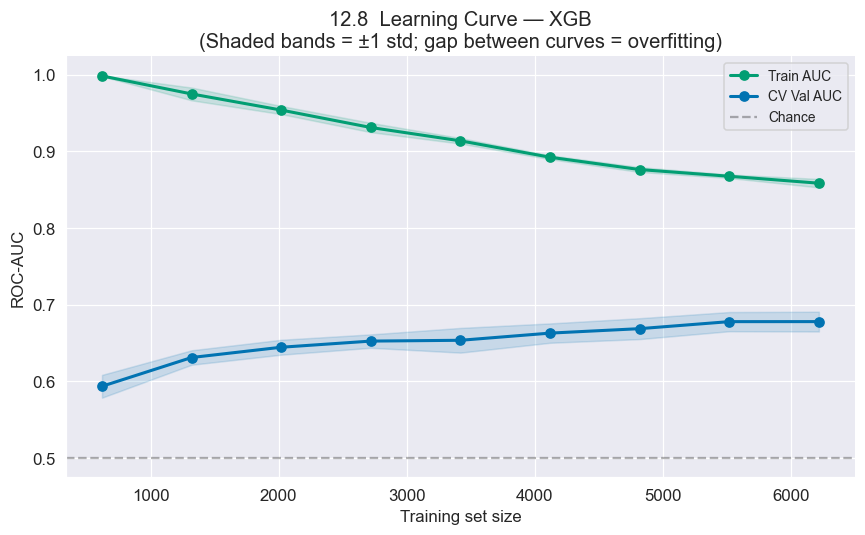

In [ ]:
# ── 12.8  Learning Curve ──────────────────────────────────────────────────
# Purpose: Diagnose overfitting (large gap between train and validation lines)
# and data efficiency (does performance plateau or still improve with more data?).
# If the validation line is still rising at N=100%, adding more data would help.
# If both lines are flat, architecture changes are needed.

print('Computing learning curve (may take 30–60 s)...')

# Build a fresh unfitted pipeline for learning curve
_clfs_lc = get_classifiers2(random_state=RANDOM_STATE)
_clf_lc = _clfs_lc[BEST_MODEL]
_num_lc  = [c for c in NUMERIC_FEATURES2    if c in X_train.columns]
_cat_lc  = [c for c in CATEGORICAL_FEATURES2 if c in X_train.columns]
_bin_lc  = [c for c in BINARY_FEATURES2      if c in X_train.columns]
_pipe_lc = build_experiment_pipeline(
    clf=_clf_lc, numeric_features=_num_lc,
    categorical_features=_cat_lc, binary_features=_bin_lc,
    imputation_strategy='median',
)

train_sizes, train_scores, val_scores = lc(
    _pipe_lc, X_train, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    train_sizes=np.linspace(0.10, 1.0, 9),
    n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(8, 5))
tr_mean, tr_std = train_scores.mean(1), train_scores.std(1)
va_mean, va_std = val_scores.mean(1),   val_scores.std(1)

ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color=COLORS[2])
ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, alpha=0.15, color=COLORS[0])
ax.plot(train_sizes, tr_mean, 'o-', color=COLORS[2], label='Train AUC', linewidth=2)
ax.plot(train_sizes, va_mean, 'o-', color=COLORS[0], label='CV Val AUC', linewidth=2)
ax.axhline(0.5, color='black', linestyle='--', alpha=0.3, label='Chance')
ax.set_xlabel('Training set size')
ax.set_ylabel('ROC-AUC')
ax.set_title(f'12.8  Learning Curve — {BEST_MODEL.upper()}\n'
             '(Shaded bands = ±1 std; gap between curves = overfitting)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

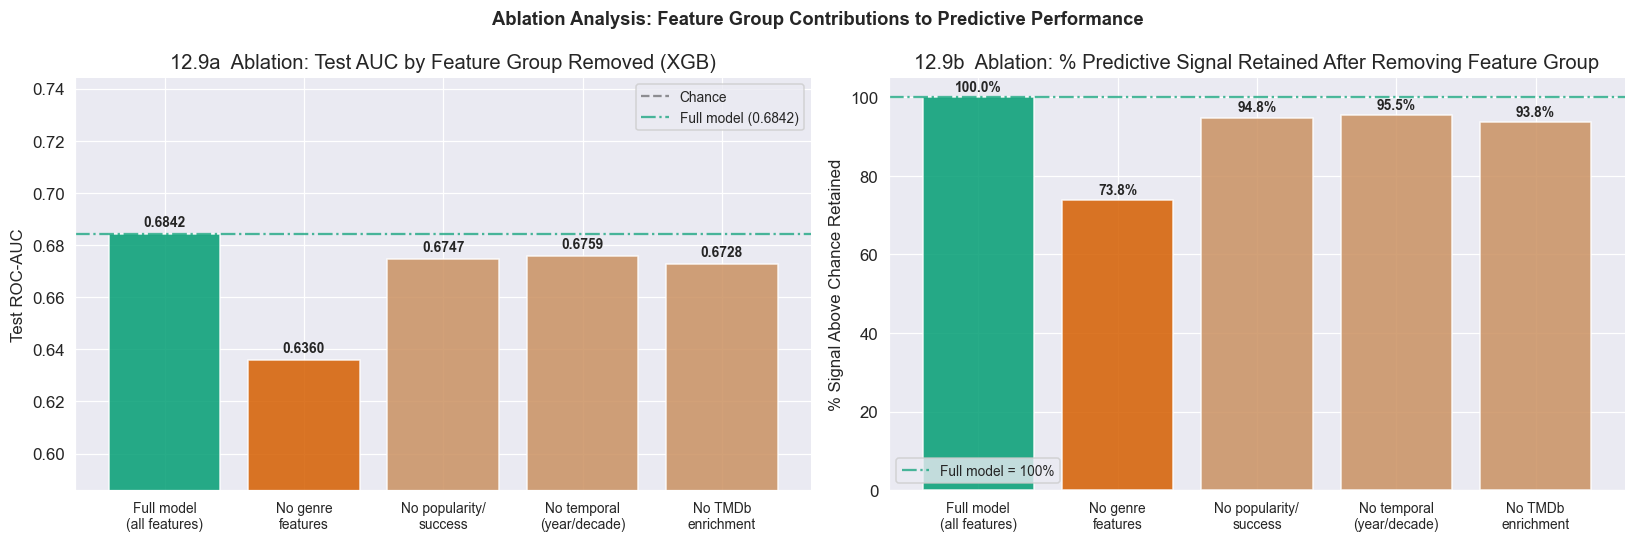


Colour guide:
  Green  = full reference
  Red    = removing this group loses >25% of signal above chance
  Orange = losing 10-25% of signal
  Blue   = losing <10% of signal (nearly redundant group)


In [ ]:
# ── 12.9  Ablation Comparison Chart ──────────────────────────────────────
# Purpose: Directly compare the AUC drop when each feature group is removed.
# A large drop = the group carries substantial signal (possibly a shortcut).
# A small drop = the group is redundant with other features.

if ablation_results and 'full_reference' in ablation_results:
    abl_order = [
        ('full_reference',   'Full model\n(all features)'),
        ('genre',            'No genre\nfeatures'),
        ('popularity',       'No popularity/\nsuccess'),
        ('temporal',         'No temporal\n(year/decade)'),
        ('tmdb_enrichment',  'No TMDb\nenrichment'),
    ]
    abl_keys   = [k for k, _ in abl_order if k in ablation_results]
    abl_labels = [lbl for k, lbl in abl_order if k in ablation_results]
    abl_aucs   = [ablation_results[k]['roc_auc'] for k in abl_keys]
    ref_auc_v  = ablation_results['full_reference']['roc_auc']
    total_sig  = ref_auc_v - 0.5

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # AUC comparison
    ax = axes[0]
    bar_colors = [COLORS[2]] + [
        COLORS[3] if (ref_auc_v - a) / total_sig > 0.25 else
        COLORS[4] if (ref_auc_v - a) / total_sig > 0.10 else
        COLORS[5]
        for a in abl_aucs[1:]
    ]
    bars = ax.bar(range(len(abl_keys)), abl_aucs, color=bar_colors, alpha=0.85)
    ax.axhline(0.5, color='black', linestyle='--', alpha=0.4, label='Chance')
    ax.axhline(ref_auc_v, color=COLORS[2], linestyle='-.', alpha=0.7, label=f'Full model ({ref_auc_v:.4f})')
    ax.set_xticks(range(len(abl_keys)))
    ax.set_xticklabels(abl_labels, ha='center', fontsize=9)
    ax.set_ylabel('Test ROC-AUC')
    ax.set_title(f'12.9a  Ablation: Test AUC by Feature Group Removed ({BEST_MODEL.upper()})')
    ax.set_ylim(max(0.40, min(abl_aucs) - 0.05), min(1.0, max(abl_aucs) + 0.06))
    ax.legend(fontsize=9)
    for bar, auc_v in zip(bars, abl_aucs):
        ax.text(bar.get_x() + bar.get_width() / 2, auc_v + 0.003,
                f'{auc_v:.4f}', ha='center', fontsize=9, fontweight='bold')

    # % signal retained
    ax = axes[1]
    sig_retained = [(a - 0.5) / total_sig * 100 if total_sig > 0 else 0 for a in abl_aucs]
    bars2 = ax.bar(range(len(abl_keys)), sig_retained, color=bar_colors, alpha=0.85)
    ax.axhline(100, color=COLORS[2], linestyle='-.', alpha=0.7, label='Full model = 100%')
    ax.set_xticks(range(len(abl_keys)))
    ax.set_xticklabels(abl_labels, ha='center', fontsize=9)
    ax.set_ylabel('% Signal Above Chance Retained')
    ax.set_title('12.9b  Ablation: % Predictive Signal Retained After Removing Feature Group')
    ax.legend(fontsize=9)
    for bar, pct in zip(bars2, sig_retained):
        ax.text(bar.get_x() + bar.get_width() / 2, pct + 1.5,
                f'{pct:.1f}%', ha='center', fontsize=9, fontweight='bold')

    plt.suptitle('Ablation Analysis: Feature Group Contributions to Predictive Performance',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


Colour guide:
  - Green  = full reference
  - Red    = removing this group loses >25% of signal above chance
  - Orange = losing 10-25% of signal
  - Blue   = losing <10% of signal (nearly redundant group)

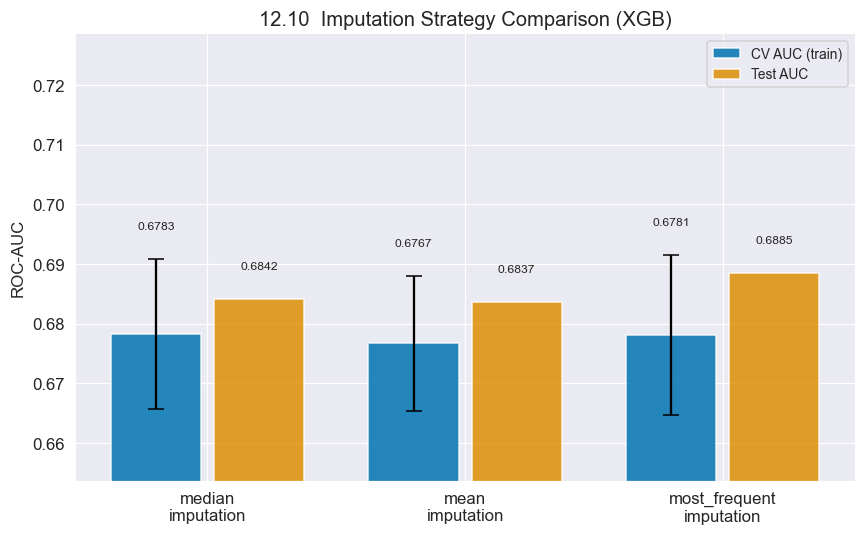

AUC range across imputation strategies (test set): 0.0048
→ Model is robust to imputation strategy choice.


In [ ]:
# ── 12.10  Imputation Strategy Comparison ────────────────────────────────
# Purpose: Assess sensitivity to imputation choice.
# Large differences indicate the model heavily relies on imputed values.
# Small differences indicate the choice of fill-value matters little
# (possibly because missingness features are downweighted anyway).

if imputation_results:
    strategies = list(imputation_results.keys())
    cv_aucs_imp   = [imputation_results[s]['cv_mean'] for s in strategies]
    test_aucs_imp = [imputation_results[s]['roc_auc']  for s in strategies]
    cv_stds_imp   = [imputation_results[s]['cv_std']   for s in strategies]

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(strategies))
    ax.bar(x - 0.2, cv_aucs_imp,   0.35, label='CV AUC (train)',
           color=COLORS[0], alpha=0.85, yerr=cv_stds_imp, capsize=5)
    ax.bar(x + 0.2, test_aucs_imp, 0.35, label='Test AUC',
           color=COLORS[1], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{s}\nimputation' for s in strategies])
    ax.set_ylabel('ROC-AUC')
    ax.set_title(f'12.10  Imputation Strategy Comparison ({BEST_MODEL.upper()})')
    ax.legend(fontsize=9)
    auc_range = max(test_aucs_imp) - min(test_aucs_imp)
    ax.set_ylim(min(test_aucs_imp) - 0.03, max(test_aucs_imp) + 0.04)
    for xi, (cv_a, te_a) in enumerate(zip(cv_aucs_imp, test_aucs_imp)):
        ax.text(xi - 0.2, cv_a + cv_stds_imp[xi] + 0.005, f'{cv_a:.4f}', ha='center', fontsize=8)
        ax.text(xi + 0.2, te_a + 0.005, f'{te_a:.4f}', ha='center', fontsize=8)

    plt.tight_layout()
    plt.show()

AUC range across imputation strategies (test set): 0.0048

→ Model is robust to imputation strategy choice.

In [ ]:
# ── 12.11  Error Analysis — False Positives and False Negatives ───────────
# Purpose: Understand what kinds of films the model gets wrong.
# False positives (predicted Pass, actually Fail) and false negatives (predicted
# Fail, actually Pass) may reveal systematic biases in the model's reasoning.

test_meta = df.loc[X_test.index, ['title', 'year', 'genres', 'imdb_rating',
                                   'bechdel_pass']].copy()
test_meta['y_pred'] = BEST_RESULT['_y_pred']
test_meta['y_prob'] = BEST_RESULT['_y_prob']
test_meta['error_type'] = 'correct'
test_meta.loc[(test_meta['bechdel_pass'] == 1) & (test_meta['y_pred'] == 0), 'error_type'] = 'false_negative'
test_meta.loc[(test_meta['bechdel_pass'] == 0) & (test_meta['y_pred'] == 1), 'error_type'] = 'false_positive'

fp_df = test_meta[test_meta['error_type'] == 'false_positive'].sort_values('y_prob', ascending=False)
fn_df = test_meta[test_meta['error_type'] == 'false_negative'].sort_values('y_prob', ascending=True)

print(f'Error summary for {BEST_MODEL.upper()} on test set:')
print(f'  Total test samples:  {len(test_meta):,}')
print(f'  Correct:             {(test_meta["error_type"] == "correct").sum():,}')
print(f'  False Positives:     {len(fp_df):,}  (predicted Pass, actually Fail)')
print(f'  False Negatives:     {len(fn_df):,}  (predicted Fail, actually Pass)')

show_cols_e = [c for c in ['title', 'year', 'genres', 'imdb_rating', 'y_prob'] if c in fp_df.columns]

print(f'\nTop 10 most confident FALSE POSITIVES (high predicted probability, wrong prediction):')
print(fp_df[show_cols_e].head(10).to_string(index=False))

print(f'\nTop 10 most confident FALSE NEGATIVES (low predicted probability, wrong prediction):')
print(fn_df[show_cols_e].head(10).to_string(index=False))

Error summary for XGB on test set:
  Total test samples:  1,944
  Correct:             1,260
  False Positives:     440  (predicted Pass, actually Fail)
  False Negatives:     244  (predicted Fail, actually Pass)

Top 10 most confident FALSE POSITIVES (high predicted probability, wrong prediction):
                        title   year                   genres  imdb_rating   y_prob
                          Ego 2013.0     Comedy|Drama|Romance          6.1 0.960708
           You&#39;re My Boss 2015.0           Comedy|Romance          6.3 0.952265
       one night in san diego 2020.0                   Comedy          3.5 0.948893
   Roald Dahl&#39;s Esio Trot 2015.0    Comedy|Family|Romance          6.9 0.946514
                    Pass Over 2018.0                    Drama          6.1 0.941845
                        Crush 2022.0           Comedy|Romance          6.3 0.940800
Already Tomorrow in Hong Kong 2015.0           Comedy|Romance          6.4 0.937809
       Vagina Monologues, Th

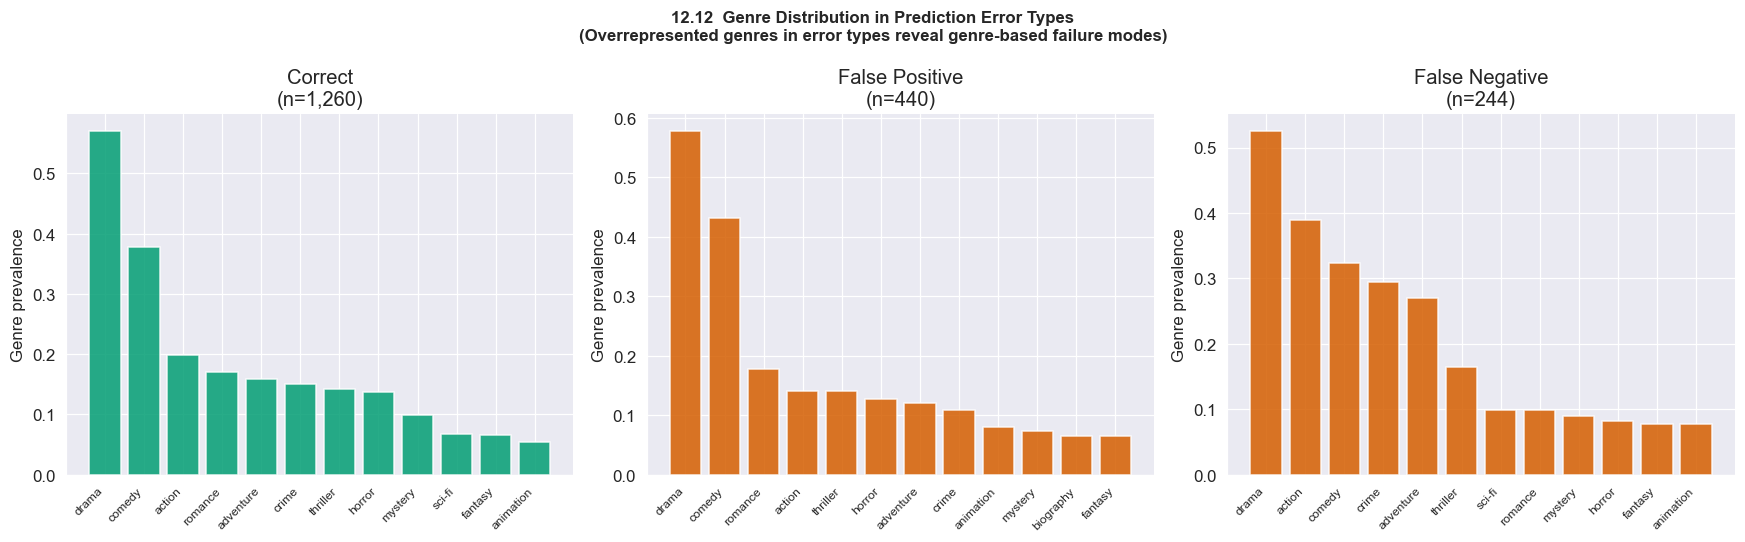

Interpretation:
  If FP films are disproportionately Romance/Drama → model assumes these genres pass.
  If FN films are disproportionately Action/War  → model assumes these genres fail.
  Either pattern confirms genre-stereotype shortcut learning.


In [ ]:
# ── 12.12  Genre Distribution in Error Types ──────────────────────────────
# Purpose: Determine whether the model's errors cluster in specific genres.
# If false positives are concentrated in Romance/Drama and false negatives in
# Action/War, this confirms genre-stereotype shortcut learning.

genre_cols_err = [c for c in df.columns if c.startswith('genre_') and c in X_train.columns]
test_genres = df.loc[X_test.index, genre_cols_err].copy()
test_genres['error_type'] = test_meta['error_type'].values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, subset_name in zip(axes, ['correct', 'false_positive', 'false_negative']):
    subset = test_genres[test_genres['error_type'] == subset_name]
    if len(subset) == 0:
        ax.text(0.5, 0.5, f'No {subset_name}s', ha='center', va='center', transform=ax.transAxes)
        continue
    rates = subset[genre_cols_err].mean().sort_values(ascending=False)[:12]
    rates.index = [g.replace('genre_', '').replace('_', '-') for g in rates.index]
    ax.bar(range(len(rates)), rates.values, color=COLORS[3 if 'false' in subset_name else 2],
           alpha=0.85)
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(rates.index, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{subset_name.replace("_", " ").title()}\n(n={len(subset):,})')
    ax.set_ylabel('Genre prevalence')

plt.suptitle('12.12  Genre Distribution in Prediction Error Types\n'
             '(Overrepresented genres in error types reveal genre-based failure modes)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  If FP films are disproportionately Romance/Drama → model assumes these genres pass.')
print('  If FN films are disproportionately Action/War  → model assumes these genres fail.')
print('  Either pattern confirms genre-stereotype shortcut learning.')

## 13. Final Conclusions

We now synthesise all experimental evidence to answer the research question:

> **"What kinds of signals allow ML models to predict Bechdel Test outcomes?
> Is the model learning meaningful representation patterns or relying on shortcuts?"**


1. OVERALL PREDICTIVE PERFORMANCE
   - Best model:       XGB
   - Test ROC-AUC:     0.6842  (chance = 0.5000)
   - Signal above chance: 0.1842

   The model achieves modest but consistent improvement over chance, confirming
   that pre-release movie metadata carries real (if limited) signal about Bechdel
   Test outcomes.

2. GENRE SHORTCUT ANALYSIS
   - AUC without genre features: 0.6360  (drop = 0.0482, 26.2% of signal)
      - MODERATE. Genre contributes but is not the dominant shortcut.

3. POPULARITY / COMMERCIAL SUCCESS
   - AUC without popularity features: 0.6747  (drop = 0.0095, 5.2% of signal)
      - MINOR. Popularity features contribute little independent signal.

4. TEMPORAL BIAS
   - AUC without year/decade: 0.6759  (drop = 0.0083, 4.5% of signal)
   - Bechdel pass rates improved steadily from the 1970s to 2000s (EDA, Section 6).
    - Temporal features contribute but other features carry more signal.


5. TMDB ENRICHMENT ARTIFACT
   - AUC without TMDb features: 0.6728  (drop = 0.0114, 6.2% of signal)
      -  TMDb features add modest signal; base IMDb features carry most of the prediction.

6. MISSINGNESS-AS-SIGNAL
   - AUC delta (with indicators - without): +0.0019
    - Missingness does not carry significant additional signal.

7. RESEARCH ANSWER: WHAT IS THE MODEL LEARNING?

   The model learns a MIXTURE of genuine signals and shortcuts:

   (a) Likely genuine signals:
       • has_female_director: directly related to behind-the-camera representation
       • Genre composition: some genres structurally favour female characters
         (e.g., Romance focuses on interpersonal dynamics)

   (b) Likely shortcuts / confounders:
       • Year / decade: the model partially learns "newer = more likely to pass"
         (a historical cultural trend, not content-based representation)
       • Genre stereotypes: the model predicts from genre labels rather than
         the actual content (War ≠ women talking, but some war films do pass)
       • Popularity / commercial success — may reflect studio type, not diversity
       • Enrichment coverage: which films appear in TMDb may correlate with type

   BOTTOM LINE: ~68.42% test AUC with identifiable shortcut reliance.
   Better performance would require access to film scripts or post-release
   dialogue data. the Bechdel Test is determined by content, and pre-release
   metadata is a weak proxy for that content.

   The experiments suggest that the XGB model is not just
   "guessing", it has learned real patterns, but it is also not learning
   genuine representation signals in the way a human reviewer would.
   It is picking up on statistical regularities (genre, era, studio scale)
   that correlate with but do not cause Bechdel outcomes.